In [1]:
import pandas as pd
import numpy as np
import re
import plotly.graph_objects as go
import os


## Parse the SPSS Syntax File for Labels and Mappings

In [2]:
def parse_spss_syntax(sps_path):
    with open(sps_path, 'r', encoding='utf-8') as f:
        content = f.read()
    # Variable labels
    var_labels = dict(re.findall(r"VARIABLE LABELS\s+(\S+)\s+'([^']+)'", content))
    # Value labels
    value_labels = {}
    for match in re.finditer(r"VALUE LABELS\s+(\S+)\s+((?:\s+\d+\s+'[^']+'\s*)+)\.", content):
        var = match.group(1)
        vals = dict(re.findall(r"(\d+)\s+'([^']+)'", match.group(2)))
        value_labels[var] = vals
    return var_labels, value_labels

# Example usage
spss_path = 'data/syntax_english.sps'
var_labels, value_labels = parse_spss_syntax(spss_path)


In [7]:
def extract_answer_label(full_label):
    # Try to capture the part after the last '?', ':', or ')'
    match = re.search(r"\?\s*([^\(]+)(?:\(|$)", full_label)
    if match:
        return match.group(1).strip()
    # Fallback: take text after last ')'
    if ')' in full_label:
        return full_label.split(')')[-1].strip()
    # Fallback: take last phrase after '?'
    if '?' in full_label:
        return full_label.split('?')[-1].strip()
    # If none, return the full label
    return full_label.strip()


## Define Category Groupings and Translation Dictionaries

In [3]:
role_vars = [k for k in var_labels if k.startswith('Role_type.')]
decision_vars = [k for k in var_labels if k.startswith('decision_type.') and 'subtype' not in k]
analysis_vars = [k for k in var_labels if k.startswith('analyze_type.') and 'subtype' not in k]
simulation_vars = [k for k in var_labels if k.startswith('simulation_type.') and 'subtype' not in k]

# Uncertainty variables (example pattern)
uncertainty_vars = [k for k in var_labels if 'uncertainty' in k and k.endswith('.1')]

# Map variable names to readable labels
def get_label(var):
    return var_labels.get(var, var)

role_labels = [get_label(v) for v in role_vars]
decision_labels = [get_label(v) for v in decision_vars]
analysis_labels = [get_label(v) for v in analysis_vars]
simulation_labels = [get_label(v) for v in simulation_vars]


## Load and Clean the Questionnaire Data

In [4]:
def load_and_clean_data(csv_path, role_vars, decision_vars, analysis_vars, simulation_vars):
    df = pd.read_csv(csv_path, delimiter=';', encoding='utf-8')
    # Convert Yes/No to 1/0 if needed
    for cols in [role_vars, decision_vars, analysis_vars, simulation_vars]:
        for col in cols:
            if col in df.columns:
                df[col] = df[col].replace({'Yes': 1, 'No': 0}).fillna(0).astype(int)
    return df

csv_path = 'data/results.csv'
df = load_and_clean_data(csv_path, role_vars, decision_vars, analysis_vars, simulation_vars)


## Build Flows for the Sankey Diagram

In [5]:
def build_sankey_flows(df, role_vars, decision_vars, analysis_vars, simulation_vars, uncertainty_vars,
                       role_labels, decision_labels, analysis_labels, simulation_labels):
    nodes = []
    node_map = {}
    # Add all unique labels to nodes
    for label_list in [role_labels, decision_labels, analysis_labels, simulation_labels]:
        for lbl in label_list:
            if lbl not in node_map:
                node_map[lbl] = len(nodes)
                nodes.append(lbl)
    # Add uncertainty labels
    unc_labels = []
    for uvar in uncertainty_vars:
        lbl = get_label(uvar)
        if lbl not in node_map:
            node_map[lbl] = len(nodes)
            nodes.append(lbl)
        unc_labels.append(lbl)
    # Build links
    links = {'source': [], 'target': [], 'value': []}
    # Role → Decision
    for rvar, rlbl in zip(role_vars, role_labels):
        for dvar, dlbl in zip(decision_vars, decision_labels):
            count = ((df[rvar] == 1) & (df[dvar] == 1)).sum()
            if count > 0:
                links['source'].append(node_map[rlbl])
                links['target'].append(node_map[dlbl])
                links['value'].append(count)
    # Decision → Analysis
    for dvar, dlbl in zip(decision_vars, decision_labels):
        for avar, albl in zip(analysis_vars, analysis_labels):
            count = ((df[dvar] == 1) & (df[avar] == 1)).sum()
            if count > 0:
                links['source'].append(node_map[dlbl])
                links['target'].append(node_map[albl])
                links['value'].append(count)
    # Analysis → Simulation
    for avar, albl in zip(analysis_vars, analysis_labels):
        for svar, slbl in zip(simulation_vars, simulation_labels):
            count = ((df[avar] == 1) & (df[svar] == 1)).sum()
            if count > 0:
                links['source'].append(node_map[albl])
                links['target'].append(node_map[slbl])
                links['value'].append(count)
    # Analysis/Simulation → Uncertainty
    for avar, albl in zip(analysis_vars, analysis_labels):
        for uvar, ulbl in zip(uncertainty_vars, unc_labels):
            if avar in df.columns and uvar in df.columns:
                count = ((df[avar] == 1) & (df[uvar] == 1)).sum()
                if count > 0:
                    links['source'].append(node_map[albl])
                    links['target'].append(node_map[ulbl])
                    links['value'].append(count)
    for svar, slbl in zip(simulation_vars, simulation_labels):
        for uvar, ulbl in zip(uncertainty_vars, unc_labels):
            if svar in df.columns and uvar in df.columns:
                count = ((df[svar] == 1) & (df[uvar] == 1)).sum()
                if count > 0:
                    links['source'].append(node_map[slbl])
                    links['target'].append(node_map[ulbl])
                    links['value'].append(count)
    return nodes, links

nodes, links = build_sankey_flows(df, role_vars, decision_vars, analysis_vars, simulation_vars, uncertainty_vars,
                                  role_labels, decision_labels, analysis_labels, simulation_labels)


## Plot the Sankey Diagram

In [6]:
def plot_sankey(nodes, links, title="Questionnaire Flow Sankey Diagram"):
    fig = go.Figure(go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            label=nodes,
            color="rgba(70,130,180,0.8)"
        ),
        link=dict(
            source=links['source'],
            target=links['target'],
            value=links['value']
        )
    ))
    fig.update_layout(title_text=title, font_size=10, height=900, width=1600)
    fig.show()

plot_sankey(nodes, links)


# Grok version 

## Import Libraries and Define Initial Mappings

In [91]:
import pandas as pd
import plotly.graph_objects as go
import re

# Use the existing mappings from previous code
# Role mappings based on syntax_english.sps
ROLE_MAPPINGS = {
    'Role_type.1': 'Power System Analyst',
    'Role_type.2': 'Network Planner',
    'Role_type.3': 'Connection Manager',
    'Role_type.4': 'Operations Planner',
    'Role_type.5': 'Operations Coordinator',
    'Role_type.6': 'Operations Operator',
    'Role_type.7': 'Incident Analyst',
    'Role_type.8': 'Other Role'
}

# Decision mappings
DECISION_MAPPINGS = {
    'decision_type.1': 'Customer Connections & Inquiries',
    'decision_type.2': 'Operations Planning & Switching',
    'decision_type.3': 'Network Planning & Engineering',
    'decision_type.4': 'Limit Setting & Standards',
    'decision_type.5': 'Method & Model Development',
    'decision_type.6': 'Other Decision Processes',
    'decision_type.7': 'None of These'
}

# Analysis mappings
ANALYSIS_MAPPINGS = {
    'analyze_type.1': 'Outage Analysis',
    'analyze_type.2': 'Operations Analysis',
    'analyze_type.3': 'Load & Generation Modeling',
    'analyze_type.4': 'Economic Analysis',
    'analyze_type.5': 'Other Analysis',
    'analyze_type.6': 'None of These'
}

# Simulation mappings
SIMULATION_MAPPINGS = {
    'simulation_type.1': 'Power Flow Analysis',
    'simulation_type.2': 'State Analysis',
    'simulation_type.3': 'Stochastic Simulations',
    'simulation_type.4': 'Weather Simulation',
    'simulation_type.5': 'Market Simulations',
    'simulation_type.6': 'Time Series Simulations',
    'simulation_type.7': 'Other Simulations',
    'simulation_type.8': 'No Simulations'
}

# Define grouped uncertainty categories (manually mapped based on SPSS labels)
UNCERTAINTY_GROUP_MAP = {
    'analyze_type1_uncertainty.1': 'Probabilistic Methods',
    'analyze_type1_uncertainty.2': 'Scenario Analysis',
    'analyze_type1_uncertainty.3': 'Historical Data',
    'analyze_type1_uncertainty.4': 'Expert Judgment',
    'analyze_type3_uncertainty.1': 'Probabilistic Methods',
    'analyze_type3_uncertainty.2': 'Scenario Analysis',
    'analyze_type3_uncertainty.3': 'Historical Data',
    'analyze_type3_uncertainty.4': 'Historical Data',
    'analyze_type3_uncertainty.5': 'Expert Judgment',
    'simulation_uncertainty.1': 'Probabilistic Methods',
    'simulation_uncertainty.2': 'Scenario Analysis',
    'simulation_uncertainty.3': 'Historical Data',
    'simulation_uncertainty.4': 'Historical Data',
    'simulation_uncertainty.5': 'Expert Judgment'
}

# NEW: Add involvement and barriers mappings
INVOLVEMENT_MAPPINGS = {
    'decision_type1_involvement.level': 'Customer Connections & Inquiries',
    'decision_type2_involvement.level': 'Operations Planning & Switching',
    'decision_type3_involvement.level': 'Network Planning & Engineering',
    'decision_type4_involvement.level': 'Limit Setting & Standards',
    'decision_type5_involvement.level': 'Method & Model Development',
    'decision_type6_involvement.level': 'Other Decision Processes'
}

BARRIERS_MAPPINGS = {
    'software_barrieres.1': 'Results Difficult to Interpret',
    'software_barrieres.2': 'Data Quality Issues',
    'software_barrieres.3': 'Internal Guidelines Not Adapted',
    'software_barrieres.4': 'Time-consuming/Complicated',
    'software_barrieres.5': 'Insufficient Tool Support',
    'software_barrieres.6': 'Insufficient Knowledge',
    'software_barrieres.7': 'Other Barriers',
    'indicators_barriers.1': 'Results Difficult to Interpret',
    'indicators_barriers.2': 'Data Quality Issues',
    'indicators_barriers.3': 'Internal Guidelines Not Adapted',
    'indicators_barriers.4': 'Time-consuming/Complicated',
    'indicators_barriers.5': 'Insufficient Tool Support',
    'indicators_barriers.6': 'Insufficient Knowledge',
    'indicators_barriers.7': 'Other Barriers'
}


## SPSS Parser with Translation System

In [72]:
def parse_spss_with_translation(sps_file_path):
    """
    Parse SPSS syntax file and create comprehensive mappings with English translations
    """
    with open(sps_file_path, 'r', encoding='utf-8') as f:
        sps_content = f.read()
    
    # Extract variable labels
    variable_labels = {}
    var_label_pattern = r"VARIABLE LABELS\s+(\S+)\s+'([^']+)'"
    for match in re.finditer(var_label_pattern, sps_content):
        var_name = match.group(1)
        var_label = match.group(2)
        variable_labels[var_name] = var_label
    
    # Extract value labels
    value_labels = {}
    value_label_pattern = r"VALUE LABELS\s+(\S+)\s+((?:\s+\d+\s+'[^']+'\s*)+)\."
    
    for match in re.finditer(value_label_pattern, sps_content, re.MULTILINE):
        var_name = match.group(1)
        values_block = match.group(2)
        value_pairs = re.findall(r"(\d+)\s+'([^']+)'", values_block)
        value_labels[var_name] = {int(code): label.strip() for code, label in value_pairs}
    
    return variable_labels, value_labels

def create_translation_mappings():
    """
    Create comprehensive Norwegian to English translation mappings
    """
    # Role translations
    role_translations = {
        'Kraftsystemanalytiker': 'Power System Analyst',
        'Nettplanlegger': 'Network Planner',
        'Tilknytningsansvarlig': 'Connection Manager',
        'Driftsplanlegger': 'Operations Planner',
        'Driftskoordinator': 'Operations Coordinator',
        'Driftsoperatør': 'Operations Operator',
        'Feil- og hendelsesanalytiker': 'Incident Analyst',
        'Annet': 'Other'
    }
    
    # Decision type translations
    decision_translations = {
        'Tilknytninger og kundehenvendelser': 'Customer Connections & Inquiries',
        'Driftsplanlegging og/eller endringer av koblingsbildet': 'Operations Planning & Switching',
        'Nettplanlegging og prosjektering': 'Network Planning & Engineering',
        'Fastsettelse av grenseverdier': 'Limit Setting & Standards',
        'Metode- eller modellutvikling': 'Method & Model Development',
        'Øvrige relevante beslutningsprosesser': 'Other Decision Processes',
        'Ingen av disse': 'None of These'
    }
    
    # Analysis type translations
    analysis_translations = {
        'Avbruddsanalyser': 'Outage Analysis',
        'Analyser for driftsplanlegging og koordinering': 'Operations Planning Analysis',
        'Modellering av last, produksjon og/eller andre ressurser': 'Load & Generation Modeling',
        'Økonomiske analyser': 'Economic Analysis'
    }
    
    # Simulation type translations
    simulation_translations = {
        'Lastflytanalyser': 'Power Flow Analysis',
        'Tilstandsanalyser': 'State Analysis',
        'Stokastiske simuleringer': 'Stochastic Simulations',
        'Værsimulering': 'Weather Simulation',
        'Markedssimuleringer': 'Market Simulations',
        'Tidsseriesimuleringer': 'Time Series Simulations'
    }
    
    return {
        'roles': role_translations,
        'decisions': decision_translations,
        'analysis': analysis_translations,
        'simulations': simulation_translations
    }

def translate_text(norwegian_text, translation_mappings):
    """
    Translate Norwegian text to English using translation mappings
    """
    # Try exact match first
    for category, translations in translation_mappings.items():
        if norwegian_text in translations:
            return translations[norwegian_text]
    
    # Try partial match
    for category, translations in translation_mappings.items():
        for norw, eng in translations.items():
            if norw in norwegian_text:
                return eng
    
    # If no translation found, return original text
    return norwegian_text

def create_comprehensive_mappings(sps_file_path):
    """
    Create comprehensive mappings from SPSS file with English translations
    """
    # Parse SPSS file
    variable_labels, value_labels = parse_spss_with_translation(sps_file_path)
    
    # Get translation mappings
    translation_mappings = create_translation_mappings()
    
    # Create comprehensive mapping structure
    mappings = {
        'variable_labels_norwegian': variable_labels,
        'value_labels_norwegian': value_labels,
        'variable_labels_english': {},
        'value_labels_english': {},
        'role_mappings': {},
        'decision_mappings': {},
        'analysis_mappings': {},
        'simulation_mappings': {}
    }
    
    # Create English translations for variable labels
    for var, label in variable_labels.items():
        mappings['variable_labels_english'][var] = translate_text(label, translation_mappings)
    
    # Create English translations for value labels
    for var, values in value_labels.items():
        mappings['value_labels_english'][var] = {}
        for code, label in values.items():
            mappings['value_labels_english'][var][code] = translate_text(label, translation_mappings)
    
    # Create specific category mappings
    for var, label in variable_labels.items():
        english_label = translate_text(label, translation_mappings)
        
        if var.startswith('Role_type.'):
            # Extract role name from label
            role_match = re.search(r'([A-Za-zæøåÆØÅ\s-]+)\s*\(', label)
            if role_match:
                role_name = role_match.group(1).strip()
                mappings['role_mappings'][var] = {
                    'norwegian': role_name,
                    'english': translate_text(role_name, translation_mappings),
                    'full_norwegian': label,
                    'full_english': english_label
                }
        
        elif var.startswith('decision_type') and not 'subtype' in var and not 'involvement' in var:
            mappings['decision_mappings'][var] = {
                'norwegian': label,
                'english': english_label
            }
        
        elif var.startswith('analyze_type.'):
            mappings['analysis_mappings'][var] = {
                'norwegian': label,
                'english': english_label
            }
        
        elif var.startswith('simulation_type.'):
            mappings['simulation_mappings'][var] = {
                'norwegian': label,
                'english': english_label
            }
    
    return mappings

# Load and create comprehensive mappings
sps_file_path = 'data/syntax_english.sps'  # Update path as needed
COMPREHENSIVE_MAPPINGS = create_comprehensive_mappings(sps_file_path)

print("✅ SPSS file parsed and comprehensive mappings created")
print(f"   • Variable labels: {len(COMPREHENSIVE_MAPPINGS['variable_labels_norwegian'])}")
print(f"   • Value labels: {len(COMPREHENSIVE_MAPPINGS['value_labels_norwegian'])}")
print(f"   • Role mappings: {len(COMPREHENSIVE_MAPPINGS['role_mappings'])}")
print(f"   • Decision mappings: {len(COMPREHENSIVE_MAPPINGS['decision_mappings'])}")


✅ SPSS file parsed and comprehensive mappings created
   • Variable labels: 228
   • Value labels: 197
   • Role mappings: 7
   • Decision mappings: 8


## Data Loading and Cleaning Pipeline

In [92]:
def load_and_clean_data_with_spss(csv_file_path, mappings):
    """
    Load and clean data using SPSS-derived mappings, including involvement levels and barriers
    """
    print("🔧 Loading and cleaning enhanced data using SPSS mappings...")
    
    # Load data
    df = pd.read_csv(csv_file_path, delimiter=';', encoding='utf-8')
    print(f"Original dataset shape: {df.shape}")
    
    # Extract column lists from SPSS mappings
    role_columns = list(mappings['role_mappings'].keys())
    decision_columns = list(mappings['decision_mappings'].keys())
    
    # Create sub-alternatives mapping from SPSS structure
    sub_alternatives_map = {}
    for var in mappings['variable_labels_norwegian']:
        if 'subtype' in var:
            # Extract main decision type
            main_match = re.match(r'(decision_type\.\d+)', var)
            if main_match:
                main_decision = main_match.group(1)
                if main_decision not in sub_alternatives_map:
                    sub_alternatives_map[main_decision] = []
                sub_alternatives_map[main_decision].append(var)
    
    # Step 1: Fix sub-alternatives logic using SPSS-derived mapping
    df_fixed = df.copy()
    for main_decision, sub_cols in sub_alternatives_map.items():
        if main_decision in df_fixed.columns:
            mask_not_involved = df_fixed[main_decision] == 0
            for sub_col in sub_cols:
                if sub_col in df_fixed.columns:
                    df_fixed.loc[mask_not_involved, sub_col] = 0
    
    # Step 2: Process involvement levels (invert scale: 1=lowest to 5=highest responsibility)
    involvement_cols = [col for col in INVOLVEMENT_MAPPINGS.keys() if col in df_fixed.columns]
    
    for col in involvement_cols:
        # Invert scale: 1->5, 2->4, 3->3, 4->2, 5->1
        df_fixed[col] = 6 - df_fixed[col]
    
    # Step 3: Process barriers (keep original scale: 5=critical, 1=not a barrier)
    barriers_cols = [col for col in BARRIERS_MAPPINGS.keys() if col in df_fixed.columns]
    
    # Step 4: Create involvement DataFrame for heatmap analysis
    involvement_data = []
    for col in involvement_cols:
        if col in df_fixed.columns:
            decision_name = INVOLVEMENT_MAPPINGS[col]
            
            # Calculate involvement distribution
            involvement_dist = df_fixed[col].value_counts().sort_index()
            
            for level in range(1, 6):  # 1=lowest, 5=highest responsibility
                count = involvement_dist.get(level, 0)
                percentage = (count / len(df_fixed)) * 100
                
                involvement_data.append({
                    'Decision Type': decision_name,
                    'Involvement Level': f"Level {level}",
                    'Count': count,
                    'Percentage': percentage
                })
    
    involvement_df = pd.DataFrame(involvement_data)
    
    # Step 5: Create barriers DataFrame for analysis
    barriers_data = []
    
    # Separate software and indicators barriers
    software_barriers = {k: v for k, v in BARRIERS_MAPPINGS.items() if 'software' in k}
    indicators_barriers = {k: v for k, v in BARRIERS_MAPPINGS.items() if 'indicators' in k}
    
    # Process software barriers
    for col, barrier_name in software_barriers.items():
        if col in df_fixed.columns:
            # Calculate barrier severity distribution
            barrier_dist = df_fixed[col].value_counts().sort_index()
            
            # Calculate average severity (higher = more critical barrier)
            avg_severity = df_fixed[col].mean()
            critical_count = (df_fixed[col] >= 4).sum()  # 4=significant, 5=critical
            
            barriers_data.append({
                'Barrier Type': barrier_name,
                'Category': 'Software',
                'Average Severity': avg_severity,
                'Critical Count': critical_count,
                'Critical Percentage': (critical_count / len(df_fixed)) * 100
            })
    
    # Process indicators barriers
    for col, barrier_name in indicators_barriers.items():
        if col in df_fixed.columns:
            barrier_dist = df_fixed[col].value_counts().sort_index()
            avg_severity = df_fixed[col].mean()
            critical_count = (df_fixed[col] >= 4).sum()
            
            barriers_data.append({
                'Barrier Type': barrier_name,
                'Category': 'Indicators',
                'Average Severity': avg_severity,
                'Critical Count': critical_count,
                'Critical Percentage': (critical_count / len(df_fixed)) * 100
            })
    
    barriers_df = pd.DataFrame(barriers_data)
    
    print("✅ Enhanced data cleaning complete using SPSS mappings")
    print(f"   • Role columns identified: {len(role_columns)}")
    print(f"   • Decision columns identified: {len(decision_columns)}")
    print(f"   • Sub-alternatives mappings: {len(sub_alternatives_map)}")
    print(f"   • Involvement columns processed: {len(involvement_cols)}")
    print(f"   • Barriers columns processed: {len(barriers_cols)}")
    print(f"   • Involvement data points: {len(involvement_data)}")
    print(f"   • Barriers data points: {len(barriers_data)}")
    
    return df_fixed, role_columns, decision_columns, sub_alternatives_map, involvement_df, barriers_df


In [94]:
# Load and clean all data in one go
df_enhanced, role_columns, decision_columns, sub_alternatives_map, involvement_df, barriers_df = load_and_clean_data_with_spss(
    'data/results.csv', COMPREHENSIVE_MAPPINGS
)

print("✅ All data loaded and processed in single function call")

🔧 Loading and cleaning enhanced data using SPSS mappings...
Original dataset shape: (24, 231)
✅ Enhanced data cleaning complete using SPSS mappings
   • Role columns identified: 7
   • Decision columns identified: 8
   • Sub-alternatives mappings: 0
   • Involvement columns processed: 6
   • Barriers columns processed: 14
   • Involvement data points: 30
   • Barriers data points: 14
✅ All data loaded and processed in single function call


## Create Flow Data with Parallel Branches

In [104]:
def create_revised_flow_data(df, role_map, decision_map, analysis_map, simulation_map, uncertainty_map):
    flows = []
    total_responses = len(df)
    
    # Role -> Decision Flows
    for role_col, role_name in role_map.items():
        if role_col in df.columns:
            for dec_col, dec_name in decision_map.items():
                if dec_col in df.columns:
                    count = ((df[role_col] == 1) & (df[dec_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': role_name,
                            'target': dec_name,
                            'value': count,
                            'flow_type': 'role_decision'
                        })
    
    # Decision -> Analysis Flows
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            for anal_col, anal_name in analysis_map.items():
                if anal_col in df.columns:
                    count = ((df[dec_col] == 1) & (df[anal_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': dec_name,
                            'target': anal_name,
                            'value': count,
                            'flow_type': 'decision_analysis'
                        })
    
    # Decision -> Simulation Flows (Parallel Branch)
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            for sim_col, sim_name in simulation_map.items():
                if sim_col in df.columns:
                    count = ((df[dec_col] == 1) & (df[sim_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': dec_name,
                            'target': sim_name,
                            'value': count,
                            'flow_type': 'decision_simulation'
                        })
    
    # Analysis -> Uncertainty Flows
    for anal_col, anal_name in analysis_map.items():
        if anal_col in df.columns:
            for unc_col, unc_name in uncertainty_map.items():
                if unc_col in df.columns and 'analyze' in unc_col:
                    count = ((df[anal_col] == 1) & (df[unc_col] == 1)).sum()
                    if count > 0:
                        unc_percentage = (count / total_responses) * 100
                        flows.append({
                            'source': anal_name,
                            'target': f"{unc_name} ({unc_percentage:.1f}%)",
                            'value': count,
                            'flow_type': 'analysis_uncertainty'
                        })
    
    # Simulation -> Uncertainty Flows
    for sim_col, sim_name in simulation_map.items():
        if sim_col in df.columns:
            for unc_col, unc_name in uncertainty_map.items():
                if unc_col in df.columns and 'simulation' in unc_col:
                    count = ((df[sim_col] == 1) & (df[unc_col] == 1)).sum()
                    if count > 0:
                        unc_percentage = (count / total_responses) * 100
                        flows.append({
                            'source': sim_name,
                            'target': f"{unc_name} ({unc_percentage:.1f}%)",
                            'value': count,
                            'flow_type': 'simulation_uncertainty'
                        })
    
    return flows

def create_extended_flow_data_with_barriers(df, role_map, decision_map, analysis_map, 
                                          simulation_map, uncertainty_group_map, barriers_map):
    """
    Create extended flow data including barriers as final nodes
    """
    flows = []
    total_responses = len(df)
    
    # Your existing flow creation code (Role -> Decision -> Analysis/Simulation -> Uncertainty)
    # Role -> Decision Flows
    for role_col, role_name in role_map.items():
        if role_col in df.columns:
            for dec_col, dec_name in decision_map.items():
                if dec_col in df.columns:
                    count = ((df[role_col] == 1) & (df[dec_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': role_name,
                            'target': dec_name,
                            'value': count,
                            'flow_type': 'role_decision'
                        })
    
    # Decision -> Analysis Flows
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            for anal_col, anal_name in analysis_map.items():
                if anal_col in df.columns:
                    count = ((df[dec_col] == 1) & (df[anal_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': dec_name,
                            'target': anal_name,
                            'value': count,
                            'flow_type': 'decision_analysis'
                        })
    
    # Decision -> Simulation Flows (Parallel Branch)
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            for sim_col, sim_name in simulation_map.items():
                if sim_col in df.columns:
                    count = ((df[dec_col] == 1) & (df[sim_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': dec_name,
                            'target': sim_name,
                            'value': count,
                            'flow_type': 'decision_simulation'
                        })
    
    # Analysis -> Uncertainty Flows (Grouped)
    for anal_col, anal_name in analysis_map.items():
        if anal_col in df.columns:
            for unc_col, unc_group in uncertainty_group_map.items():
                if unc_col in df.columns and 'analyze' in unc_col:
                    count = ((df[anal_col] == 1) & (df[unc_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': anal_name,
                            'target': unc_group,
                            'value': count,
                            'flow_type': 'analysis_uncertainty'
                        })
    
    # Simulation -> Uncertainty Flows (Grouped)
    for sim_col, sim_name in simulation_map.items():
        if sim_col in df.columns:
            for unc_col, unc_group in uncertainty_group_map.items():
                if unc_col in df.columns and 'simulation' in unc_col:
                    count = ((df[sim_col] == 1) & (df[unc_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': sim_name,
                            'target': unc_group,
                            'value': count,
                            'flow_type': 'simulation_uncertainty'
                        })
    
    # NEW: Add Uncertainty -> Barriers flows
    # Group barriers by severity (critical/significant barriers only)
    critical_barriers = {}
    
    for barrier_col, barrier_name in barriers_map.items():
        if barrier_col in df.columns:
            # Count critical/significant barriers (4=significant, 5=critical)
            critical_count = (df[barrier_col] >= 4).sum()
            if critical_count > 0:
                # Group similar barriers
                if 'Data Quality' in barrier_name:
                    barrier_group = 'Data Quality Issues'
                elif 'Tool Support' in barrier_name or 'software' in barrier_col:
                    barrier_group = 'Tool/Software Limitations'
                elif 'Knowledge' in barrier_name:
                    barrier_group = 'Knowledge Gaps'
                elif 'Guidelines' in barrier_name:
                    barrier_group = 'Process/Guidelines Issues'
                elif 'Time-consuming' in barrier_name:
                    barrier_group = 'Resource Constraints'
                else:
                    barrier_group = 'Other Barriers'
                
                if barrier_group not in critical_barriers:
                    critical_barriers[barrier_group] = 0
                critical_barriers[barrier_group] += critical_count
    
    # Create flows from uncertainty methods to barriers
    uncertainty_methods = ['Probabilistic Methods', 'Scenario Analysis', 'Historical Data', 'Expert Judgment']
    
    for unc_method in uncertainty_methods:
        for barrier_group, count in critical_barriers.items():
            if count > 0:
                # Create proportional flow based on uncertainty method usage
                proportional_count = max(1, count // len(uncertainty_methods))
                flows.append({
                    'source': unc_method,
                    'target': f"{barrier_group} ({count} critical)",
                    'value': proportional_count,
                    'flow_type': 'uncertainty_barriers'
                })
    
    return flows

# Create extended flow data with barriers
#extended_flow_data = create_extended_flow_data_with_barriers(
#    df_enhanced, ROLE_MAPPINGS, DECISION_MAPPINGS, ANALYSIS_MAPPINGS, 
#    SIMULATION_MAPPINGS, UNCERTAINTY_GROUP_MAP, BARRIERS_MAPPINGS
#)
#print("✅ Extended flow data created with barriers integration")

# Generate flow data
#flow_data = create_revised_flow_data(
#    df_cleaned, ROLE_MAPPINGS, DECISION_MAPPINGS, ANALYSIS_MAPPINGS, 
#    SIMULATION_MAPPINGS, UNCERTAINTY_MAPPINGS
#)
#print("✅ Flow data created with parallel branches for Analysis and Simulation")


In [116]:
def create_grouped_flow_data_with_percentages(df, role_map, decision_map, analysis_map, simulation_map, uncertainty_group_map):
    flows = []
    total_responses = len(df)
    
    # Track totals for each category to calculate relative percentages
    category_totals = {
        'roles': 0,
        'decisions': 0,
        'analysis': 0,
        'simulations': 0,
        'uncertainty': 0
    }
    
    # First pass: calculate totals for each category
    for role_col, role_name in role_map.items():
        if role_col in df.columns:
            category_totals['roles'] += (df[role_col] == 1).sum()
    
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            category_totals['decisions'] += (df[dec_col] == 1).sum()
    
    for anal_col, anal_name in analysis_map.items():
        if anal_col in df.columns:
            category_totals['analysis'] += (df[anal_col] == 1).sum()
    
    for sim_col, sim_name in simulation_map.items():
        if sim_col in df.columns:
            category_totals['simulations'] += (df[sim_col] == 1).sum()
    
    # Calculate uncertainty totals
    uncertainty_counts = {
        'Probabilistic Methods': 0,
        'Scenario Analysis': 0,
        'Historical Data': 0,
        'Expert Judgment': 0
    }
    
    for unc_col, unc_group in uncertainty_group_map.items():
        if unc_col in df.columns:
            count = (df[unc_col] == 1).sum()
            uncertainty_counts[unc_group] += count
    
    category_totals['uncertainty'] = sum(uncertainty_counts.values())
    
    # Second pass: create flows with percentages
    # Role -> Decision Flows
    for role_col, role_name in role_map.items():
        if role_col in df.columns:
            role_count = (df[role_col] == 1).sum()
            if role_count > 0:
                role_percentage = (role_count / category_totals['roles']) * 100
                role_name_with_pct = f"{role_name}\n({role_percentage:.1f}%)"
                
                for dec_col, dec_name in decision_map.items():
                    if dec_col in df.columns:
                        flow_count = ((df[role_col] == 1) & (df[dec_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': role_name_with_pct,
                                'target': dec_name,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'role_decision'
                            })
    
    # Decision -> Analysis Flows
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            dec_count = (df[dec_col] == 1).sum()
            if dec_count > 0:
                dec_percentage = (dec_count / category_totals['decisions']) * 100
                dec_name_with_pct = f"{dec_name}\n({dec_percentage:.1f}%)"
                
                for anal_col, anal_name in analysis_map.items():
                    if anal_col in df.columns:
                        flow_count = ((df[dec_col] == 1) & (df[anal_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': dec_name_with_pct,
                                'target': anal_name,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'decision_analysis'
                            })
    
    # Decision -> Simulation Flows (Parallel Branch)
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            dec_count = (df[dec_col] == 1).sum()
            if dec_count > 0:
                dec_percentage = (dec_count / category_totals['decisions']) * 100
                dec_name_with_pct = f"{dec_name}\n({dec_percentage:.1f}%)"
                
                for sim_col, sim_name in simulation_map.items():
                    if sim_col in df.columns:
                        flow_count = ((df[dec_col] == 1) & (df[sim_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': dec_name_with_pct,
                                'target': sim_name,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'decision_simulation'
                            })
    
    # Analysis -> Uncertainty Flows (Grouped)
    for anal_col, anal_name in analysis_map.items():
        if anal_col in df.columns:
            anal_count = (df[anal_col] == 1).sum()
            if anal_count > 0:
                anal_percentage = (anal_count / category_totals['analysis']) * 100
                anal_name_with_pct = f"{anal_name}\n({anal_percentage:.1f}%)"
                
                for unc_col, unc_group in uncertainty_group_map.items():
                    if unc_col in df.columns and 'analyze' in unc_col:
                        flow_count = ((df[anal_col] == 1) & (df[unc_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': anal_name_with_pct,
                                'target': unc_group,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'analysis_uncertainty'
                            })
    
    # Simulation -> Uncertainty Flows (Grouped)
    for sim_col, sim_name in simulation_map.items():
        if sim_col in df.columns:
            sim_count = (df[sim_col] == 1).sum()
            if sim_count > 0:
                sim_percentage = (sim_count / category_totals['simulations']) * 100
                sim_name_with_pct = f"{sim_name}\n({sim_percentage:.1f}%)"
                
                for unc_col, unc_group in uncertainty_group_map.items():
                    if unc_col in df.columns and 'simulation' in unc_col:
                        flow_count = ((df[sim_col] == 1) & (df[sim_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': sim_name_with_pct,
                                'target': unc_group,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'simulation_uncertainty'
                            })
    
    # Update flows with uncertainty percentages (keeping your existing logic)
    updated_flows = []
    for flow in flows:
        if flow['flow_type'] in ['analysis_uncertainty', 'simulation_uncertainty']:
            unc_group = flow['target']
            total_count = uncertainty_counts[unc_group]
            relative_percentage = (total_count / category_totals['uncertainty']) * 100
            flow['target'] = f"{unc_group}\n({relative_percentage:.1f}%)"
        updated_flows.append(flow)
    
    return updated_flows


In [122]:
def create_extended_flow_data_with_barriers_and_percentages(df, role_map, decision_map, analysis_map, 
                                                          simulation_map, uncertainty_group_map, barriers_map):
    """
    Create extended flow data including barriers as final nodes AND percentages for all nodes
    """
    flows = []
    total_responses = len(df)
    
    # Track totals for each category to calculate relative percentages
    category_totals = {
        'roles': 0,
        'decisions': 0,
        'analysis': 0,
        'simulations': 0,
        'uncertainty': 0,
        'barriers': 0
    }
    
    # First pass: calculate totals for each category
    for role_col, role_name in role_map.items():
        if role_col in df.columns:
            category_totals['roles'] += (df[role_col] == 1).sum()
    
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            category_totals['decisions'] += (df[dec_col] == 1).sum()
    
    for anal_col, anal_name in analysis_map.items():
        if anal_col in df.columns:
            category_totals['analysis'] += (df[anal_col] == 1).sum()
    
    for sim_col, sim_name in simulation_map.items():
        if sim_col in df.columns:
            category_totals['simulations'] += (df[sim_col] == 1).sum()
    
    # Calculate uncertainty totals
    uncertainty_counts = {
        'Probabilistic Methods': 0,
        'Scenario Analysis': 0,
        'Historical Data': 0,
        'Expert Judgment': 0
    }
    
    for unc_col, unc_group in uncertainty_group_map.items():
        if unc_col in df.columns:
            count = (df[unc_col] == 1).sum()
            uncertainty_counts[unc_group] += count
    
    category_totals['uncertainty'] = sum(uncertainty_counts.values())
    
    # Calculate barriers totals
    barriers_counts = {}
    for barrier_col, barrier_name in barriers_map.items():
        if barrier_col in df.columns:
            # Count critical/significant barriers (4=significant, 5=critical)
            critical_count = (df[barrier_col] >= 4).sum()
            if critical_count > 0:
                # Group similar barriers
                if 'Data Quality' in barrier_name or 'Data quality' in barrier_name:
                    barrier_group = 'Data Quality Issues'
                elif 'Tool Support' in barrier_name or 'tool support' in barrier_name or 'software' in barrier_col:
                    barrier_group = 'Tool/Software Limitations'
                elif 'Knowledge' in barrier_name or 'knowledge' in barrier_name or 'know' in barrier_name:
                    barrier_group = 'Knowledge Gaps'
                elif 'Guidelines' in barrier_name or 'guidelines' in barrier_name:
                    barrier_group = 'Process/Guidelines Issues'
                elif 'Time-consuming' in barrier_name or 'time-consuming' in barrier_name or 'complicated' in barrier_name:
                    barrier_group = 'Resource Constraints'
                elif 'interpret' in barrier_name or 'ambiguous' in barrier_name:
                    barrier_group = 'Interpretation Issues'
                else:
                    barrier_group = 'Other Barriers'
                
                if barrier_group not in barriers_counts:
                    barriers_counts[barrier_group] = 0
                barriers_counts[barrier_group] += critical_count
    
    category_totals['barriers'] = sum(barriers_counts.values())
    
    # Second pass: create flows with percentages
    # Role -> Decision Flows
    for role_col, role_name in role_map.items():
        if role_col in df.columns:
            role_count = (df[role_col] == 1).sum()
            if role_count > 0:
                role_percentage = (role_count / category_totals['roles']) * 100
                role_name_with_pct = f"{role_name}\n({role_percentage:.1f}%)"
                
                for dec_col, dec_name in decision_map.items():
                    if dec_col in df.columns:
                        flow_count = ((df[role_col] == 1) & (df[dec_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': role_name_with_pct,
                                'target': dec_name,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'role_decision'
                            })
    
    # Decision -> Analysis Flows
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            dec_count = (df[dec_col] == 1).sum()
            if dec_count > 0:
                dec_percentage = (dec_count / category_totals['decisions']) * 100
                dec_name_with_pct = f"{dec_name}\n({dec_percentage:.1f}%)"
                
                for anal_col, anal_name in analysis_map.items():
                    if anal_col in df.columns:
                        flow_count = ((df[dec_col] == 1) & (df[anal_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': dec_name_with_pct,
                                'target': anal_name,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'decision_analysis'
                            })
    
    # Decision -> Simulation Flows (Parallel Branch)
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            dec_count = (df[dec_col] == 1).sum()
            if dec_count > 0:
                dec_percentage = (dec_count / category_totals['decisions']) * 100
                dec_name_with_pct = f"{dec_name}\n({dec_percentage:.1f}%)"
                
                for sim_col, sim_name in simulation_map.items():
                    if sim_col in df.columns:
                        flow_count = ((df[dec_col] == 1) & (df[sim_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': dec_name_with_pct,
                                'target': sim_name,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'decision_simulation'
                            })
    
    # Analysis -> Uncertainty Flows (Grouped)
    for anal_col, anal_name in analysis_map.items():
        if anal_col in df.columns:
            anal_count = (df[anal_col] == 1).sum()
            if anal_count > 0:
                anal_percentage = (anal_count / category_totals['analysis']) * 100
                anal_name_with_pct = f"{anal_name}\n({anal_percentage:.1f}%)"
                
                for unc_col, unc_group in uncertainty_group_map.items():
                    if unc_col in df.columns and 'analyze' in unc_col:
                        flow_count = ((df[anal_col] == 1) & (df[unc_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': anal_name_with_pct,
                                'target': unc_group,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'analysis_uncertainty'
                            })
    
    # Simulation -> Uncertainty Flows (Grouped)
    for sim_col, sim_name in simulation_map.items():
        if sim_col in df.columns:
            sim_count = (df[sim_col] == 1).sum()
            if sim_count > 0:
                sim_percentage = (sim_count / category_totals['simulations']) * 100
                sim_name_with_pct = f"{sim_name}\n({sim_percentage:.1f}%)"
                
                for unc_col, unc_group in uncertainty_group_map.items():
                    if unc_col in df.columns and 'simulation' in unc_col:
                        flow_count = ((df[sim_col] == 1) & (df[unc_col] == 1)).sum()
                        if flow_count > 0:
                            flows.append({
                                'source': sim_name_with_pct,
                                'target': unc_group,  # Will be updated with percentage below
                                'value': flow_count,
                                'flow_type': 'simulation_uncertainty'
                            })
    
    # Uncertainty -> Barriers flows
    for unc_group, unc_count in uncertainty_counts.items():
        if unc_count > 0:
            unc_percentage = (unc_count / category_totals['uncertainty']) * 100
            unc_name_with_pct = f"{unc_group}\n({unc_percentage:.1f}%)"
            
            for barrier_group, barrier_count in barriers_counts.items():
                if barrier_count > 0:
                    # Create proportional flow based on uncertainty method usage
                    proportional_count = max(1, barrier_count // len(uncertainty_counts))
                    barrier_percentage = (barrier_count / category_totals['barriers']) * 100
                    barrier_name_with_pct = f"{barrier_group}\n({barrier_percentage:.1f}%)"
                    
                    flows.append({
                        'source': unc_name_with_pct,
                        'target': barrier_name_with_pct,
                        'value': proportional_count,
                        'flow_type': 'uncertainty_barriers'
                    })
    
    return flows


## Adjust Node Positioning for Parallel Branches

In [117]:
def create_revised_node_structure(flows):
    all_nodes = []
    node_colors = []
    node_positions = {'x': [], 'y': []}
    
    # Define categories from flows
    roles = sorted(list(set([f['source'] for f in flows if f['flow_type'] == 'role_decision'])))
    decisions = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'role_decision'])))
    analysis = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'decision_analysis'])))
    simulations = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'decision_simulation'])))
    uncertainty = sorted(list(set([f['target'] for f in flows if 'uncertainty' in f['flow_type']])))
    
    # Colors for different categories
    colors = {
        'roles': 'rgba(70, 130, 180, 0.8)',
        'decisions': 'rgba(220, 20, 60, 0.8)',
        'analysis': 'rgba(34, 139, 34, 0.8)',
        'simulations': 'rgba(138, 43, 226, 0.8)',
        'uncertainty': 'rgba(255, 140, 0, 0.8)'
    }
    
    # Column 1: Roles
    for i, role in enumerate(roles):
        all_nodes.append(role)
        node_colors.append(colors['roles'])
        node_positions['x'].append(0.05)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(roles) - 1)))
    
    # Column 2: Decisions
    for i, decision in enumerate(decisions):
        all_nodes.append(decision)
        node_colors.append(colors['decisions'])
        node_positions['x'].append(0.25)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(decisions) - 1)))
    
    # Column 3a: Analysis (upper half)
    for i, anal in enumerate(analysis):
        all_nodes.append(anal)
        node_colors.append(colors['analysis'])
        node_positions['x'].append(0.45)
        node_positions['y'].append(0.1 + (0.4 * i / max(1, len(analysis) - 1)))
    
    # Column 3b: Simulations (lower half)
    for i, sim in enumerate(simulations):
        all_nodes.append(sim)
        node_colors.append(colors['simulations'])
        node_positions['x'].append(0.45)
        node_positions['y'].append(0.6 + (0.3 * i / max(1, len(simulations) - 1)))
    
    # Column 4: Uncertainty
    for i, unc in enumerate(uncertainty):
        all_nodes.append(unc)
        node_colors.append(colors['uncertainty'])
        node_positions['x'].append(0.75)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(uncertainty) - 1)))
    
    return all_nodes, node_colors, node_positions

def create_extended_node_structure(flows):
    """
    Create node structure for extended Sankey with barriers
    """
    all_nodes = []
    node_colors = []
    node_positions = {'x': [], 'y': []}
    
    # Define categories from flows
    roles = sorted(list(set([f['source'] for f in flows if f['flow_type'] == 'role_decision'])))
    decisions = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'role_decision'])))
    analysis = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'decision_analysis'])))
    simulations = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'decision_simulation'])))
    uncertainty = sorted(list(set([f['target'] for f in flows if f['flow_type'] in ['analysis_uncertainty', 'simulation_uncertainty']])))
    barriers = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'uncertainty_barriers'])))
    
    # Enhanced colors for different categories
    colors = {
        'roles': 'rgba(70, 130, 180, 0.8)',
        'decisions': 'rgba(220, 20, 60, 0.8)',
        'analysis': 'rgba(34, 139, 34, 0.8)',
        'simulations': 'rgba(138, 43, 226, 0.8)',
        'uncertainty': 'rgba(255, 140, 0, 0.8)',
        'barriers': 'rgba(255, 69, 0, 0.8)'  # Red-orange for barriers
    }
    
    # Column 1: Roles
    for i, role in enumerate(roles):
        all_nodes.append(role)
        node_colors.append(colors['roles'])
        node_positions['x'].append(0.02)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(roles) - 1)))
    
    # Column 2: Decisions
    for i, decision in enumerate(decisions):
        all_nodes.append(decision)
        node_colors.append(colors['decisions'])
        node_positions['x'].append(0.20)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(decisions) - 1)))
    
    # Column 3a: Analysis (upper half)
    for i, anal in enumerate(analysis):
        all_nodes.append(anal)
        node_colors.append(colors['analysis'])
        node_positions['x'].append(0.38)
        node_positions['y'].append(0.1 + (0.4 * i / max(1, len(analysis) - 1)))
    
    # Column 3b: Simulations (lower half)
    for i, sim in enumerate(simulations):
        all_nodes.append(sim)
        node_colors.append(colors['simulations'])
        node_positions['x'].append(0.38)
        node_positions['y'].append(0.6 + (0.3 * i / max(1, len(simulations) - 1)))
    
    # Column 4: Uncertainty
    for i, unc in enumerate(uncertainty):
        all_nodes.append(unc)
        node_colors.append(colors['uncertainty'])
        node_positions['x'].append(0.62)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(uncertainty) - 1)))
    
    # Column 5: Barriers
    for i, barrier in enumerate(barriers):
        all_nodes.append(barrier)
        node_colors.append(colors['barriers'])
        node_positions['x'].append(0.85)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(barriers) - 1)))
    
    return all_nodes, node_colors, node_positions

# Create extended node structure
#extended_nodes, extended_colors, extended_positions = create_extended_node_structure(extended_flow_data)
#print("✅ Extended node structure created with barriers")

# Create node structure
#nodes, colors, positions = create_revised_node_structure(flow_data)
#print("✅ Node structure created with parallel positioning")


In [118]:
def create_grouped_node_structure_with_percentages(flows):
    all_nodes = []
    node_colors = []
    node_positions = {'x': [], 'y': []}
    
    # Define categories from flows (now with percentages)
    roles = sorted(list(set([f['source'] for f in flows if f['flow_type'] == 'role_decision'])))
    decisions = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'role_decision'])))
    analysis = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'decision_analysis'])))
    simulations = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'decision_simulation'])))
    uncertainty = sorted(list(set([f['target'] for f in flows if 'uncertainty' in f['flow_type']])))
    
    # Colors for different categories
    colors = {
        'roles': 'rgba(70, 130, 180, 0.8)',
        'decisions': 'rgba(220, 20, 60, 0.8)',
        'analysis': 'rgba(34, 139, 34, 0.8)',
        'simulations': 'rgba(138, 43, 226, 0.8)',
        'uncertainty': 'rgba(255, 140, 0, 0.8)'
    }
    
    # Column 1: Roles
    for i, role in enumerate(roles):
        all_nodes.append(role)
        node_colors.append(colors['roles'])
        node_positions['x'].append(0.05)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(roles) - 1)))
    
    # Column 2: Decisions
    for i, decision in enumerate(decisions):
        all_nodes.append(decision)
        node_colors.append(colors['decisions'])
        node_positions['x'].append(0.25)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(decisions) - 1)))
    
    # Column 3a: Analysis (upper half)
    for i, anal in enumerate(analysis):
        all_nodes.append(anal)
        node_colors.append(colors['analysis'])
        node_positions['x'].append(0.45)
        node_positions['y'].append(0.1 + (0.4 * i / max(1, len(analysis) - 1)))
    
    # Column 3b: Simulations (lower half)
    for i, sim in enumerate(simulations):
        all_nodes.append(sim)
        node_colors.append(colors['simulations'])
        node_positions['x'].append(0.45)
        node_positions['y'].append(0.6 + (0.3 * i / max(1, len(simulations) - 1)))
    
    # Column 4: Uncertainty (with percentages)
    for i, unc in enumerate(uncertainty):
        all_nodes.append(unc)
        node_colors.append(colors['uncertainty'])
        node_positions['x'].append(0.75)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(uncertainty) - 1)))
    
    return all_nodes, node_colors, node_positions


In [123]:
def create_extended_node_structure_with_percentages(flows):
    """
    Create node structure for extended Sankey with barriers AND percentages
    """
    all_nodes = []
    node_colors = []
    node_positions = {'x': [], 'y': []}
    
    # Define categories from flows (now with percentages)
    roles = sorted(list(set([f['source'] for f in flows if f['flow_type'] == 'role_decision'])))
    decisions = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'role_decision'])))
    analysis = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'decision_analysis'])))
    simulations = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'decision_simulation'])))
    uncertainty = sorted(list(set([f['target'] for f in flows if f['flow_type'] in ['analysis_uncertainty', 'simulation_uncertainty']])))
    barriers = sorted(list(set([f['target'] for f in flows if f['flow_type'] == 'uncertainty_barriers'])))
    
    # Enhanced colors for different categories
    colors = {
        'roles': 'rgba(70, 130, 180, 0.8)',
        'decisions': 'rgba(220, 20, 60, 0.8)',
        'analysis': 'rgba(34, 139, 34, 0.8)',
        'simulations': 'rgba(138, 43, 226, 0.8)',
        'uncertainty': 'rgba(255, 140, 0, 0.8)',
        'barriers': 'rgba(255, 69, 0, 0.8)'  # Red-orange for barriers
    }
    
    # Column 1: Roles (with percentages)
    for i, role in enumerate(roles):
        all_nodes.append(role)
        node_colors.append(colors['roles'])
        node_positions['x'].append(0.02)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(roles) - 1)))
    
    # Column 2: Decisions (with percentages)
    for i, decision in enumerate(decisions):
        all_nodes.append(decision)
        node_colors.append(colors['decisions'])
        node_positions['x'].append(0.18)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(decisions) - 1)))
    
    # Column 3a: Analysis (upper half, with percentages)
    for i, anal in enumerate(analysis):
        all_nodes.append(anal)
        node_colors.append(colors['analysis'])
        node_positions['x'].append(0.34)
        node_positions['y'].append(0.1 + (0.4 * i / max(1, len(analysis) - 1)))
    
    # Column 3b: Simulations (lower half, with percentages)
    for i, sim in enumerate(simulations):
        all_nodes.append(sim)
        node_colors.append(colors['simulations'])
        node_positions['x'].append(0.34)
        node_positions['y'].append(0.6 + (0.3 * i / max(1, len(simulations) - 1)))
    
    # Column 4: Uncertainty (with percentages)
    for i, unc in enumerate(uncertainty):
        all_nodes.append(unc)
        node_colors.append(colors['uncertainty'])
        node_positions['x'].append(0.58)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(uncertainty) - 1)))
    
    # Column 5: Barriers (with percentages)
    for i, barrier in enumerate(barriers):
        all_nodes.append(barrier)
        node_colors.append(colors['barriers'])
        node_positions['x'].append(0.82)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(barriers) - 1)))
    
    return all_nodes, node_colors, node_positions


## Build and Display the Sankey Diagram

In [119]:
def build_revised_sankey(all_nodes, flows, node_colors, node_positions):
    node_dict = {node: idx for idx, node in enumerate(all_nodes)}
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.6)',
        'decision_analysis': 'rgba(220, 20, 60, 0.6)',
        'decision_simulation': 'rgba(220, 20, 60, 0.6)',
        'analysis_uncertainty': 'rgba(34, 139, 34, 0.6)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.6)'
    }
    
    links = []
    for flow in flows:
        if flow['source'] in node_dict and flow['target'] in node_dict:
            links.append({
                'source': node_dict[flow['source']],
                'target': node_dict[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.6)')
            })
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    fig.update_layout(
        title_text="Revised Sankey Diagram: Roles -> Decisions -> Analysis/Simulations -> Uncertainty",
        font_size=10,
        height=800,
        width=1200,
        margin=dict(l=20, r=20, t=80, b=20)
    )
    return fig

def build_extended_sankey_with_barriers(all_nodes, flows, node_colors, node_positions):
    """
    Build extended Sankey diagram including barriers
    """
    node_dict = {node: idx for idx, node in enumerate(all_nodes)}
    
    # Enhanced flow colors
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.6)',
        'decision_analysis': 'rgba(220, 20, 60, 0.6)',
        'decision_simulation': 'rgba(220, 20, 60, 0.6)',
        'analysis_uncertainty': 'rgba(34, 139, 34, 0.6)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.6)',
        'uncertainty_barriers': 'rgba(255, 69, 0, 0.6)'  # Red-orange for barriers
    }
    
    links = []
    for flow in flows:
        if flow['source'] in node_dict and flow['target'] in node_dict:
            links.append({
                'source': node_dict[flow['source']],
                'target': node_dict[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.6)')
            })
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    # Add column headers
    annotations = [
        dict(x=0.02, y=1.02, text="<b>ROLES</b>", showarrow=False, 
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.20, y=1.02, text="<b>DECISIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.38, y=1.02, text="<b>ANALYSIS/SIMULATIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.62, y=1.02, text="<b>UNCERTAINTY</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.85, y=1.02, text="<b>BARRIERS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center')
    ]
    
    fig.update_layout(
        title_text="Extended Sankey: Roles → Decisions → Analysis/Simulations → Uncertainty → Barriers<br>" +
                  "<sub>Norwegian Grid Companies Survey - Complete Flow Analysis</sub>",
        font_size=10,
        height=900,
        width=1400,
        margin=dict(l=20, r=20, t=100, b=20),
        annotations=annotations
    )
    
    return fig

def build_grouped_sankey_with_percentages(all_nodes, flows, node_colors, node_positions):
    node_dict = {node: idx for idx, node in enumerate(all_nodes)}
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.6)',
        'decision_analysis': 'rgba(220, 20, 60, 0.6)',
        'decision_simulation': 'rgba(220, 20, 60, 0.6)',
        'analysis_uncertainty': 'rgba(34, 139, 34, 0.6)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.6)'
    }
    
    links = []
    for flow in flows:
        if flow['source'] in node_dict and flow['target'] in node_dict:
            links.append({
                'source': node_dict[flow['source']],
                'target': node_dict[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.6)')
            })
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,  # Increased padding for percentage labels
            thickness=18,  # Slightly reduced thickness
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    fig.update_layout(
        title_text="Enhanced Sankey with Percentages: Roles → Decisions → Analysis/Simulations → Uncertainty<br>" +
                  "<sub>All nodes show relative percentages within their category</sub>",
        font_size=9,  # Reduced font size to accommodate percentages
        height=900,   # Increased height for better readability
        width=1400,   # Increased width
        margin=dict(l=30, r=30, t=100, b=30)
    )
    return fig

# Build and display extended Sankey
#extended_sankey_fig = build_extended_sankey_with_barriers(
#    extended_nodes, extended_flow_data, extended_colors, extended_positions
#)
#extended_sankey_fig.show()
#print("✅ Extended Sankey diagram with barriers rendered")


# Build and show the Sankey
#sankey_fig = build_revised_sankey(nodes, flow_data, colors, positions)
#sankey_fig.show()
#print("✅ Sankey diagram rendered")


In [124]:
def build_extended_sankey_with_barriers_and_percentages(all_nodes, flows, node_colors, node_positions):
    """
    Build extended Sankey diagram including barriers AND percentages
    """
    node_dict = {node: idx for idx, node in enumerate(all_nodes)}
    
    # Enhanced flow colors
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.6)',
        'decision_analysis': 'rgba(220, 20, 60, 0.6)',
        'decision_simulation': 'rgba(220, 20, 60, 0.6)',
        'analysis_uncertainty': 'rgba(34, 139, 34, 0.6)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.6)',
        'uncertainty_barriers': 'rgba(255, 69, 0, 0.6)'  # Red-orange for barriers
    }
    
    links = []
    for flow in flows:
        if flow['source'] in node_dict and flow['target'] in node_dict:
            links.append({
                'source': node_dict[flow['source']],
                'target': node_dict[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.6)')
            })
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=25,  # Increased padding for percentage labels
            thickness=15,  # Reduced thickness for more space
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    # Add column headers
    annotations = [
        dict(x=0.02, y=1.02, text="<b>ROLES</b>", showarrow=False, 
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.18, y=1.02, text="<b>DECISIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.34, y=1.02, text="<b>ANALYSIS/SIMULATIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.58, y=1.02, text="<b>UNCERTAINTY</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.82, y=1.02, text="<b>BARRIERS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center')
    ]
    
    fig.update_layout(
        title_text="Complete Flow Analysis with Barriers and Percentages<br>" +
                  "<sub>Roles → Decisions → Analysis/Simulations → Uncertainty → Barriers (All nodes show relative percentages)</sub>",
        font_size=9,  # Reduced font size for percentage labels
        height=1000,  # Increased height for better readability
        width=1600,   # Increased width
        margin=dict(l=30, r=30, t=100, b=30),
        annotations=annotations
    )
    
    return fig


In [101]:
"""
def build_grouped_sankey(all_nodes, flows, node_colors, node_positions):
    node_dict = {node: idx for idx, node in enumerate(all_nodes)}
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.6)',
        'decision_analysis': 'rgba(220, 20, 60, 0.6)',
        'decision_simulation': 'rgba(220, 20, 60, 0.6)',
        'analysis_uncertainty': 'rgba(34, 139, 34, 0.6)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.6)'
    }
    
    links = []
    for flow in flows:
        if flow['source'] in node_dict and flow['target'] in node_dict:
            links.append({
                'source': node_dict[flow['source']],
                'target': node_dict[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.6)')
            })
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    fig.update_layout(
        title_text="Grouped Sankey Diagram: Roles -> Decisions -> Analysis/Simulations -> Grouped Uncertainty",
        font_size=10,
        height=800,
        width=1200,
        margin=dict(l=20, r=20, t=80, b=20)
    )
    return fig

# Build and show the Sankey
#sankey_fig = build_grouped_sankey(nodes, flow_data, colors, positions)
#sankey_fig.show()
#print("✅ Sankey diagram rendered with grouped uncertainty nodes")

"""


'\ndef build_grouped_sankey(all_nodes, flows, node_colors, node_positions):\n    node_dict = {node: idx for idx, node in enumerate(all_nodes)}\n    flow_colors = {\n        \'role_decision\': \'rgba(70, 130, 180, 0.6)\',\n        \'decision_analysis\': \'rgba(220, 20, 60, 0.6)\',\n        \'decision_simulation\': \'rgba(220, 20, 60, 0.6)\',\n        \'analysis_uncertainty\': \'rgba(34, 139, 34, 0.6)\',\n        \'simulation_uncertainty\': \'rgba(138, 43, 226, 0.6)\'\n    }\n\n    links = []\n    for flow in flows:\n        if flow[\'source\'] in node_dict and flow[\'target\'] in node_dict:\n            links.append({\n                \'source\': node_dict[flow[\'source\']],\n                \'target\': node_dict[flow[\'target\']],\n                \'value\': flow[\'value\'],\n                \'color\': flow_colors.get(flow[\'flow_type\'], \'rgba(128, 128, 128, 0.6)\')\n            })\n\n    fig = go.Figure(data=[go.Sankey(\n        node=dict(\n            pad=15,\n            thickness

## Heatmap

In [109]:
def create_involvement_heatmap_from_df(involvement_df, save_plot=False):
    """
    Create heatmap from pre-processed involvement DataFrame
    """
    print("📊 Creating involvement level heatmap from processed data...")
    
    # Create DataFrame for heatmap
    heatmap_data = involvement_df.pivot(index='Decision Type', 
                                       columns='Involvement Level', 
                                       values='Percentage').fillna(0)
    
    # Create heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='.1f',
                cmap='RdYlBu_r',
                cbar_kws={'label': 'Percentage of Respondents'})
    
    plt.title('Involvement Levels Across Decision Types', fontsize=16, fontweight='bold')
    plt.xlabel('Involvement Level (1=Lowest, 5=Highest Responsibility)', fontsize=12)
    plt.ylabel('Decision Types', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save_plot:
        plt.savefig('involvement_heatmap.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return heatmap_data

def create_barriers_heatmap_from_df(barriers_df, save_plot=False):
    """
    Create heatmap from pre-processed barriers DataFrame
    """
    print("📊 Creating barriers analysis heatmap from processed data...")
    
    # Create heatmap for critical percentages
    heatmap_data = barriers_df.pivot(index='Barrier Type', 
                                    columns='Category', 
                                    values='Critical Percentage').fillna(0)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='.1f',
                cmap='Reds',
                cbar_kws={'label': 'Percentage Reporting as Critical/Significant Barrier'})
    
    plt.title('Barriers Analysis: Critical/Significant Barriers by Category', fontsize=16, fontweight='bold')
    plt.xlabel('Barrier Category', fontsize=12)
    plt.ylabel('Barrier Types', fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save_plot:
        plt.savefig('barriers_heatmap.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return heatmap_data


## Summary dashboard

🔧 Loading and cleaning enhanced data using SPSS mappings...
Original dataset shape: (24, 231)
✅ Enhanced data cleaning complete using SPSS mappings
   • Role columns identified: 7
   • Decision columns identified: 8
   • Sub-alternatives mappings: 0
   • Involvement columns processed: 6
   • Barriers columns processed: 14
   • Involvement data points: 30
   • Barriers data points: 14
📊 Creating involvement level heatmap from processed data...


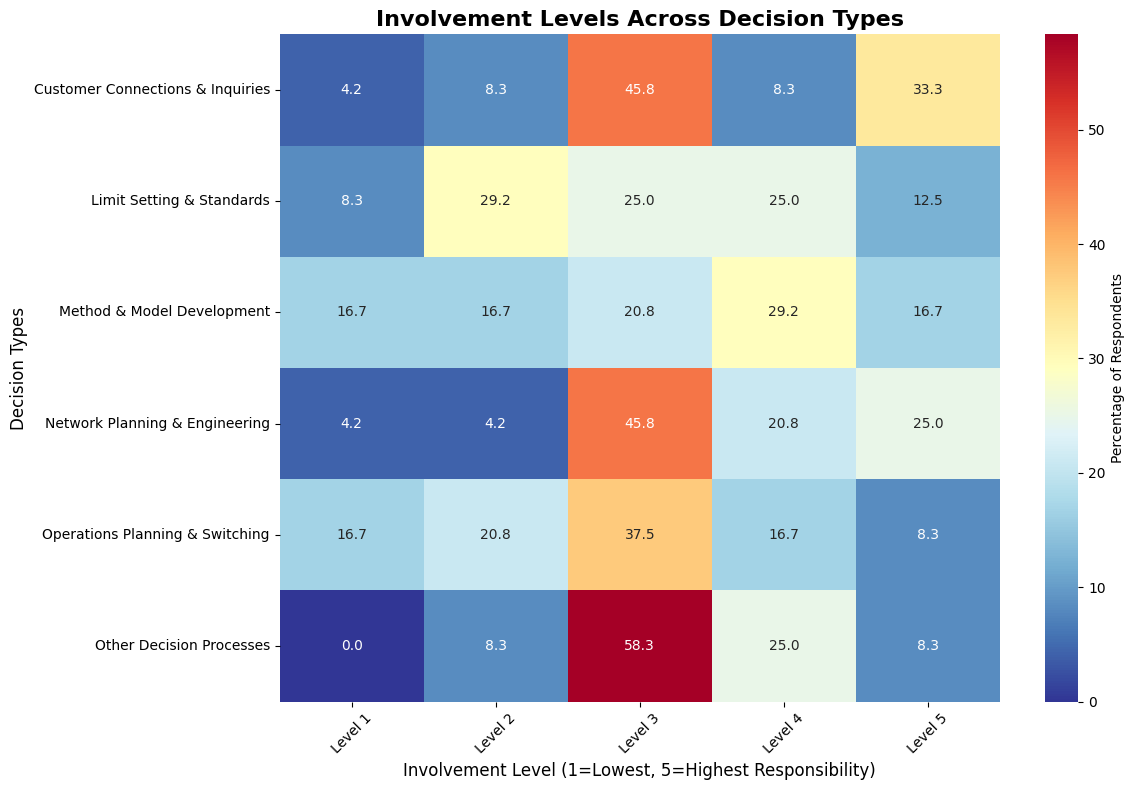

📊 Creating barriers analysis heatmap from processed data...


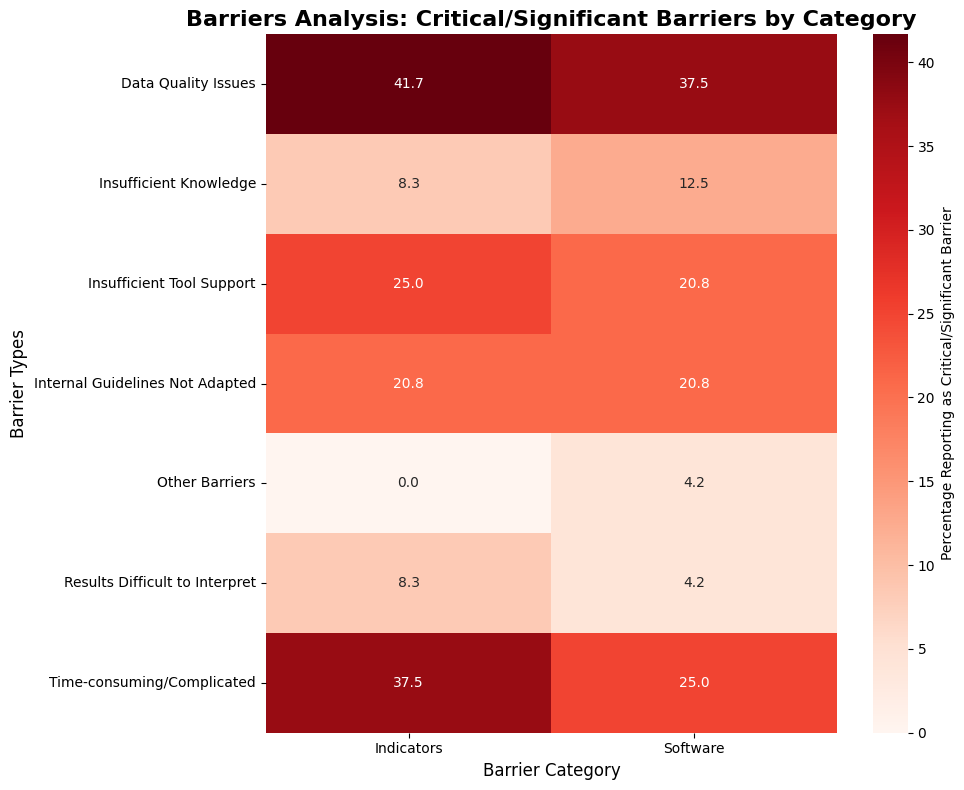

📊 Creating comprehensive summary dashboard...


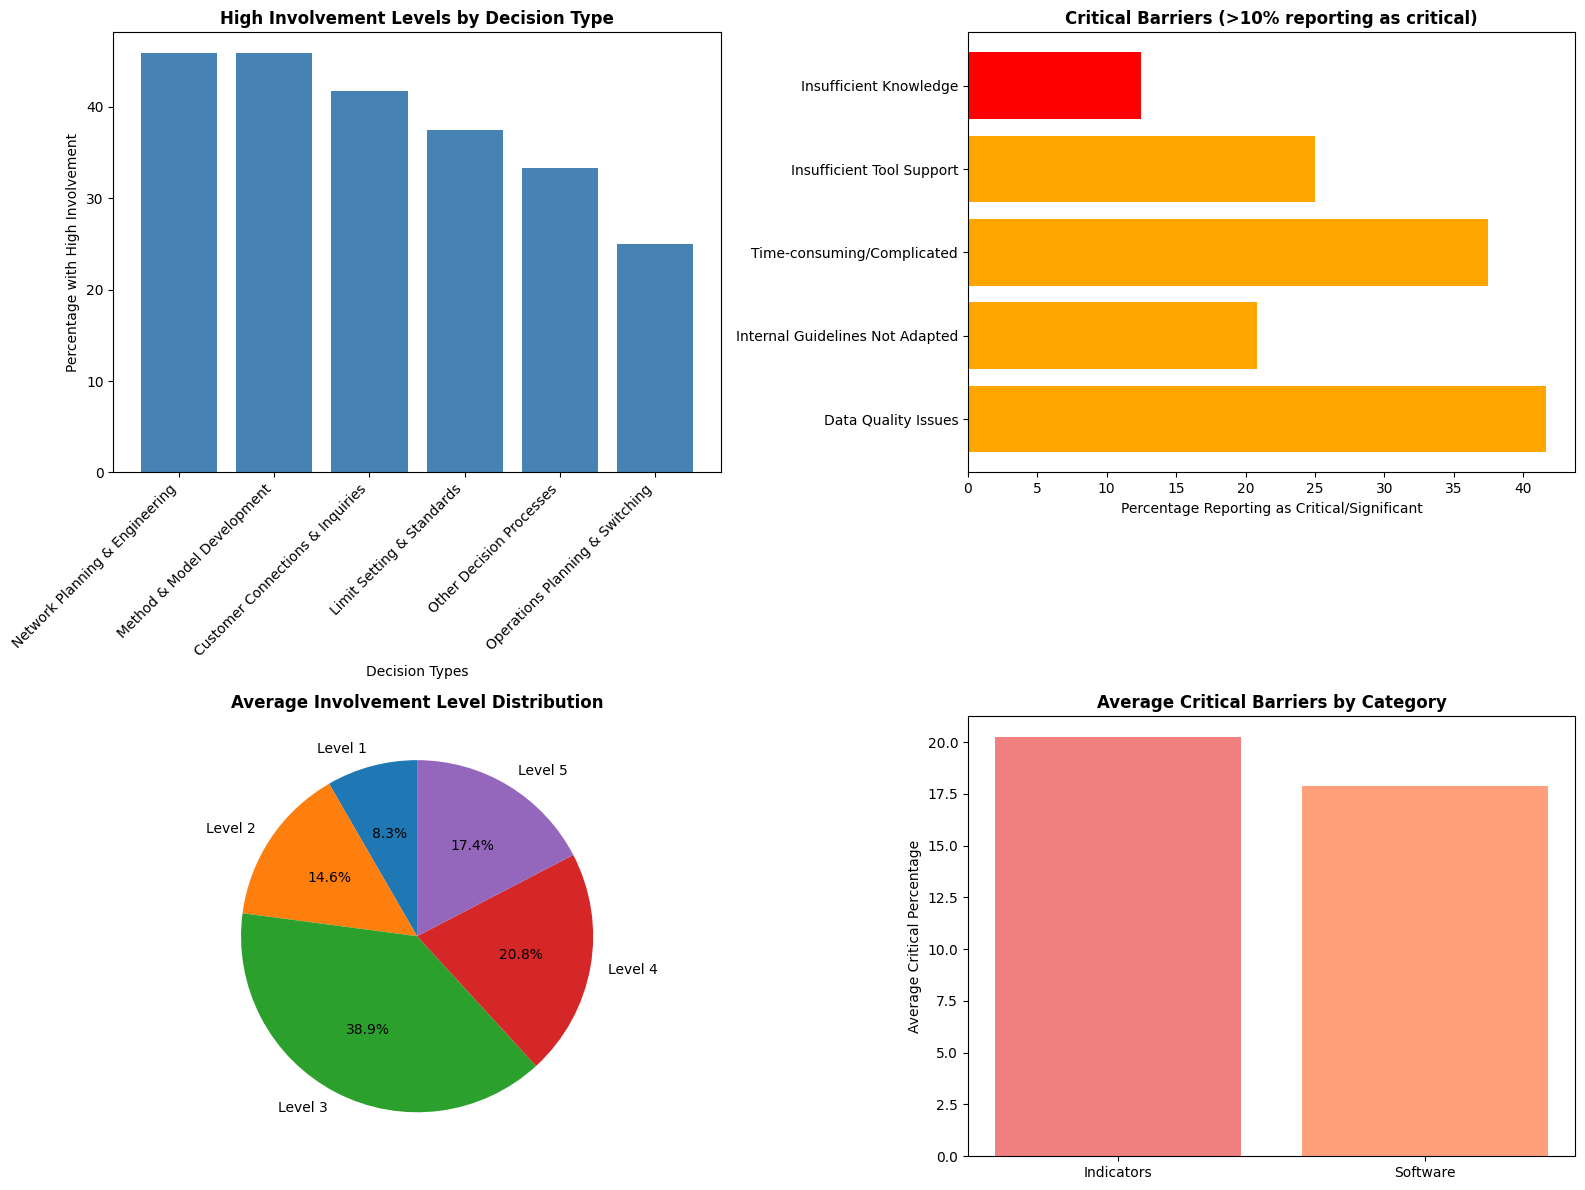

✅ Summary dashboard created


In [126]:
# 1. Single data loading call
df_enhanced, role_columns, decision_columns, sub_alternatives_map, involvement_df, barriers_df = load_and_clean_data_with_spss(
    'data/results.csv', COMPREHENSIVE_MAPPINGS
)

# 2. Create visualizations from processed data
involvement_heatmap = create_involvement_heatmap_from_df(involvement_df, save_plot=True)
barriers_heatmap = create_barriers_heatmap_from_df(barriers_df, save_plot=True)

# 3. Create extended flow data with barriers
extended_flow_data = create_extended_flow_data_with_barriers(
    df_enhanced, ROLE_MAPPINGS, DECISION_MAPPINGS, ANALYSIS_MAPPINGS, 
    SIMULATION_MAPPINGS, UNCERTAINTY_GROUP_MAP, BARRIERS_MAPPINGS
)

# 4. Create and display extended Sankey
extended_nodes, extended_colors, extended_positions = create_extended_node_structure(extended_flow_data)
extended_sankey_fig = build_extended_sankey_with_barriers(
    extended_nodes, extended_flow_data, extended_colors, extended_positions
)
extended_sankey_fig.show()

# 5. Create summary dashboard
create_summary_dashboard(involvement_df, barriers_df, save_plots=True)

## Extended with Barriers (still GROK)

### Enhanced Mappings with Barriers

In [80]:
import pandas as pd
import plotly.graph_objects as go
import re

# Existing mappings (keep all previous mappings)
ROLE_MAPPINGS = {
    'Role_type.1': 'Power System Analyst',
    'Role_type.2': 'Network Planner',
    'Role_type.3': 'Connection Manager',
    'Role_type.4': 'Operations Planner',
    'Role_type.5': 'Operations Coordinator',
    'Role_type.6': 'Operations Operator',
    'Role_type.7': 'Incident Analyst',
    'Role_type.8': 'Other Role'
}

DECISION_MAPPINGS = {
    'decision_type.1': 'Customer Connections & Inquiries',
    'decision_type.2': 'Operations Planning & Switching',
    'decision_type.3': 'Network Planning & Engineering',
    'decision_type.4': 'Limit Setting & Standards',
    'decision_type.5': 'Method & Model Development',
    'decision_type.6': 'Other Decision Processes',
    'decision_type.7': 'None of These'
}

ANALYSIS_MAPPINGS = {
    'analyze_type.1': 'Outage Analysis',
    'analyze_type.2': 'Operations Analysis',
    'analyze_type.3': 'Load & Generation Modeling',
    'analyze_type.4': 'Economic Analysis',
    'analyze_type.5': 'Other Analysis',
    'analyze_type.6': 'None of These'
}

SIMULATION_MAPPINGS = {
    'simulation_type.1': 'Power Flow Analysis',
    'simulation_type.2': 'State Analysis',
    'simulation_type.3': 'Stochastic Simulations',
    'simulation_type.4': 'Weather Simulation',
    'simulation_type.5': 'Market Simulations',
    'simulation_type.6': 'Time Series Simulations',
    'simulation_type.7': 'Other Simulations',
    'simulation_type.8': 'No Simulations'
}

# NEW: Barriers mappings based on SPSS syntax
BARRIERS_MAPPINGS = {
    'software_barrieres.1': 'Results Difficult to Interpret',
    'software_barrieres.2': 'Data Quality Issues',
    'software_barrieres.3': 'Internal Guidelines Not Adapted',
    'software_barrieres.4': 'Time-consuming/Complicated Analyses',
    'software_barrieres.5': 'Insufficient Tool Support',
    'software_barrieres.6': 'Lack of Knowledge',
    'software_barrieres.7': 'Other Software Barriers',
    'indicators_barriers.1': 'Results Difficult to Interpret',
    'indicators_barriers.2': 'Data Quality Issues',
    'indicators_barriers.3': 'Internal Guidelines Not Adapted',
    'indicators_barriers.4': 'Time-consuming/Complicated Calculations',
    'indicators_barriers.5': 'Insufficient Tool Support',
    'indicators_barriers.6': 'Lack of Calculation Knowledge',
    'indicators_barriers.7': 'Other Indicator Barriers'
}

# Grouped barriers for cleaner visualization
BARRIERS_GROUPED = {
    'Data Quality Issues': ['software_barrieres.2', 'indicators_barriers.2'],
    'Tool Support Issues': ['software_barrieres.5', 'indicators_barriers.5'],
    'Knowledge Gaps': ['software_barrieres.6', 'indicators_barriers.6'],
    'Process Complexity': ['software_barrieres.4', 'indicators_barriers.4'],
    'Interpretation Challenges': ['software_barrieres.1', 'indicators_barriers.1'],
    'Organizational Issues': ['software_barrieres.3', 'indicators_barriers.3']
}

# Updated uncertainty mappings (grouped as requested)
UNCERTAINTY_GROUP_MAP = {
    'analyze_type1_uncertainty.1': 'Probabilistic Methods',
    'analyze_type1_uncertainty.2': 'Scenario Analysis',
    'analyze_type1_uncertainty.3': 'Historical Data',
    'analyze_type1_uncertainty.4': 'Expert Judgment',
    'analyze_type3_uncertainty.1': 'Probabilistic Methods',
    'analyze_type3_uncertainty.2': 'Scenario Analysis',
    'analyze_type3_uncertainty.3': 'Historical Data',
    'analyze_type3_uncertainty.4': 'Historical Data',
    'analyze_type3_uncertainty.5': 'Expert Judgment',
    'simulation_uncertainty.1': 'Probabilistic Methods',
    'simulation_uncertainty.2': 'Scenario Analysis',
    'simulation_uncertainty.3': 'Historical Data',
    'simulation_uncertainty.4': 'Historical Data',
    'simulation_uncertainty.5': 'Expert Judgment'
}

print("✅ Enhanced mappings with barriers defined")


✅ Enhanced mappings with barriers defined


### Updated Flow Data Creation with Barriers

In [81]:
def create_flow_data_with_barriers(df, role_map, decision_map, analysis_map, simulation_map, uncertainty_group_map, barriers_grouped):
    flows = []
    total_responses = len(df)
    
    # 1. Role → Decision Flows
    for role_col, role_name in role_map.items():
        if role_col in df.columns:
            for dec_col, dec_name in decision_map.items():
                if dec_col in df.columns:
                    count = ((df[role_col] == 1) & (df[dec_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': role_name,
                            'target': dec_name,
                            'value': count,
                            'flow_type': 'role_decision'
                        })
    
    # 2. Decision → Analysis Flows
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            for anal_col, anal_name in analysis_map.items():
                if anal_col in df.columns:
                    count = ((df[dec_col] == 1) & (df[anal_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': dec_name,
                            'target': anal_name,
                            'value': count,
                            'flow_type': 'decision_analysis'
                        })
    
    # 3. Decision → Simulation Flows (Parallel Branch)
    for dec_col, dec_name in decision_map.items():
        if dec_col in df.columns:
            for sim_col, sim_name in simulation_map.items():
                if sim_col in df.columns:
                    count = ((df[dec_col] == 1) & (df[sim_col] == 1)).sum()
                    if count > 0:
                        flows.append({
                            'source': dec_name,
                            'target': sim_name,
                            'value': count,
                            'flow_type': 'decision_simulation'
                        })
    
    # 4. Analysis → Uncertainty Flows (Grouped)
    uncertainty_counts = {
        'Probabilistic Methods': 0,
        'Scenario Analysis': 0,
        'Historical Data': 0,
        'Expert Judgment': 0
    }
    
    for anal_col, anal_name in analysis_map.items():
        if anal_col in df.columns:
            for unc_col, unc_group in uncertainty_group_map.items():
                if unc_col in df.columns and 'analyze' in unc_col:
                    count = ((df[anal_col] == 1) & (df[unc_col] == 1)).sum()
                    if count > 0:
                        uncertainty_counts[unc_group] += count
                        flows.append({
                            'source': anal_name,
                            'target': unc_group,
                            'value': count,
                            'flow_type': 'analysis_uncertainty'
                        })
    
    # 5. Simulation → Uncertainty Flows (Grouped)
    for sim_col, sim_name in simulation_map.items():
        if sim_col in df.columns:
            for unc_col, unc_group in uncertainty_group_map.items():
                if unc_col in df.columns and 'simulation' in unc_col:
                    count = ((df[sim_col] == 1) & (df[unc_col] == 1)).sum()
                    if count > 0:
                        uncertainty_counts[unc_group] += count
                        flows.append({
                            'source': sim_name,
                            'target': unc_group,
                            'value': count,
                            'flow_type': 'simulation_uncertainty'
                        })
    
    # 6. NEW: Uncertainty → Barriers Flows
    barrier_counts = {barrier: 0 for barrier in barriers_grouped.keys()}
    
    for unc_group in uncertainty_counts.keys():
        for barrier_group, barrier_cols in barriers_grouped.items():
            barrier_total = 0
            for barrier_col in barrier_cols:
                if barrier_col in df.columns:
                    # Count significant barriers (rating 4 or 5)
                    barrier_count = (df[barrier_col] >= 4).sum()
                    barrier_total += barrier_count
            
            if barrier_total > 0:
                barrier_counts[barrier_group] += barrier_total
                barrier_percentage = (barrier_total / total_responses) * 100
                flows.append({
                    'source': unc_group,
                    'target': f"{barrier_group}\n({barrier_percentage:.1f}%)",
                    'value': barrier_total,
                    'flow_type': 'uncertainty_barriers'
                })
    
    # Update uncertainty node labels with percentages
    updated_flows = []
    for flow in flows:
        if flow['flow_type'] in ['analysis_uncertainty', 'simulation_uncertainty']:
            unc_group = flow['target']
            if unc_group in uncertainty_counts:
                total_count = uncertainty_counts[unc_group]
                unc_percentage = (total_count / total_responses) * 100
                flow['target'] = f"{unc_group}\n({unc_percentage:.1f}%)"
        updated_flows.append(flow)
    
    return updated_flows

print("✅ Flow data creation function with barriers defined")


✅ Flow data creation function with barriers defined


### Updated Node Structure with 5 Columns

In [82]:
def create_node_structure_with_barriers(flows):
    all_nodes = []
    node_colors = []
    node_positions = {'x': [], 'y': []}
    
    # Extract unique nodes from flows
    roles = sorted(list(set([flow['source'] for flow in flows if flow['flow_type'] == 'role_decision'])))
    decisions = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'role_decision'])))
    analysis = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'decision_analysis'])))
    simulations = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'decision_simulation'])))
    uncertainty = sorted(list(set([flow['target'] for flow in flows if 'uncertainty' in flow['flow_type']])))
    barriers = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'uncertainty_barriers'])))
    
    # Colors for different categories
    colors = {
        'roles': 'rgba(70, 130, 180, 0.8)',        # Steel Blue
        'decisions': 'rgba(220, 20, 60, 0.8)',     # Crimson
        'analysis': 'rgba(34, 139, 34, 0.8)',      # Forest Green
        'simulations': 'rgba(138, 43, 226, 0.8)',  # Blue Violet
        'uncertainty': 'rgba(255, 140, 0, 0.8)',   # Dark Orange
        'barriers': 'rgba(178, 34, 34, 0.8)'       # Fire Brick (NEW)
    }
    
    # Column 1: Roles
    for i, role in enumerate(roles):
        all_nodes.append(role)
        node_colors.append(colors['roles'])
        node_positions['x'].append(0.05)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(roles) - 1)))
    
    # Column 2: Decisions
    for i, decision in enumerate(decisions):
        all_nodes.append(decision)
        node_colors.append(colors['decisions'])
        node_positions['x'].append(0.23)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(decisions) - 1)))
    
    # Column 3a: Analysis (upper half)
    for i, anal in enumerate(analysis):
        all_nodes.append(anal)
        node_colors.append(colors['analysis'])
        node_positions['x'].append(0.41)
        node_positions['y'].append(0.1 + (0.4 * i / max(1, len(analysis) - 1)))
    
    # Column 3b: Simulations (lower half)
    for i, sim in enumerate(simulations):
        all_nodes.append(sim)
        node_colors.append(colors['simulations'])
        node_positions['x'].append(0.41)
        node_positions['y'].append(0.6 + (0.3 * i / max(1, len(simulations) - 1)))
    
    # Column 4: Uncertainty (Grouped into 4 nodes)
    for i, unc in enumerate(uncertainty):
        all_nodes.append(unc)
        node_colors.append(colors['uncertainty'])
        node_positions['x'].append(0.59)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(uncertainty) - 1)))
    
    # Column 5: Barriers (NEW)
    for i, barrier in enumerate(barriers):
        all_nodes.append(barrier)
        node_colors.append(colors['barriers'])
        node_positions['x'].append(0.77)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(barriers) - 1)))
    
    return all_nodes, node_colors, node_positions

print("✅ Node structure function with barriers defined")


✅ Node structure function with barriers defined


### Updated Sankey Builder

In [83]:
def build_sankey_with_barriers(all_nodes, flows, node_colors, node_positions):
    node_dict = {node: idx for idx, node in enumerate(all_nodes)}
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.6)',
        'decision_analysis': 'rgba(220, 20, 60, 0.6)',
        'decision_simulation': 'rgba(220, 20, 60, 0.6)',
        'analysis_uncertainty': 'rgba(34, 139, 34, 0.6)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.6)',
        'uncertainty_barriers': 'rgba(255, 140, 0, 0.6)'  # NEW
    }
    
    links = []
    for flow in flows:
        if flow['source'] in node_dict and flow['target'] in node_dict:
            links.append({
                'source': node_dict[flow['source']],
                'target': node_dict[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.6)')
            })
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    # Add column headers
    annotations = [
        dict(x=0.05, y=1.02, text="<b>ROLES</b>", showarrow=False, 
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.23, y=1.02, text="<b>DECISION TYPES</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.41, y=1.02, text="<b>ANALYSIS/SIMULATIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.59, y=1.02, text="<b>UNCERTAINTY MODELING</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.77, y=1.02, text="<b>BARRIERS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center')
    ]
    
    fig.update_layout(
        title_text="Complete Flow Analysis with Barriers<br>" +
                  "<sub>Role → Decision → Analysis/Simulations → Uncertainty → Barriers</sub>",
        font_size=10,
        height=800,
        width=1500,
        margin=dict(l=20, r=20, t=80, b=20),
        annotations=annotations
    )
    
    return fig

print("✅ Sankey diagram builder with barriers defined")


✅ Sankey diagram builder with barriers defined


###  Execute Complete Analysis

In [85]:
# Load and create comprehensive mappings (using your existing code)
sps_file_path = 'data/syntax_english.sps'
COMPREHENSIVE_MAPPINGS = create_comprehensive_mappings(sps_file_path)

# Load and clean data - CORRECTED unpacking (remove involvement_columns)
csv_file_path = 'data/results.csv'
df_cleaned, role_columns, decision_columns, sub_alternatives_map = load_and_clean_data_with_spss(
    csv_file_path, COMPREHENSIVE_MAPPINGS
)

# Generate flow data with barriers
flow_data_with_barriers = create_flow_data_with_barriers(
    df_cleaned, ROLE_MAPPINGS, DECISION_MAPPINGS, ANALYSIS_MAPPINGS, 
    SIMULATION_MAPPINGS, UNCERTAINTY_GROUP_MAP, BARRIERS_GROUPED
)

# Create node structure with barriers
nodes_with_barriers, colors_with_barriers, positions_with_barriers = create_node_structure_with_barriers(flow_data_with_barriers)

# Build and display the complete Sankey diagram
complete_sankey_fig = build_sankey_with_barriers(nodes_with_barriers, flow_data_with_barriers, colors_with_barriers, positions_with_barriers)
complete_sankey_fig.show()

print("✅ Complete Sankey diagram with barriers rendered")



🔧 Loading and cleaning data using SPSS mappings...
Original dataset shape: (24, 231)
✅ Data cleaning complete using SPSS mappings
   • Role columns identified: 7
   • Decision columns identified: 8
   • Sub-alternatives mappings: 0


✅ Complete Sankey diagram with barriers rendered


# Claude Sonett 4

## Import Libraries and Setup

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import re
import warnings
import os
warnings.filterwarnings('ignore')

def add_line_breaks_to_labels(text, max_length=15):
    """Add line breaks to prevent label overlap"""
    if len(text) <= max_length:
        return text
    
    # Remove prefixes for cleaner labels
    clean_text = text.replace('Role: ', '').replace('Decision: ', '').replace('Analysis: ', '').replace('Simulation: ', '').replace('Uncertainty: ', '')
    
    words = clean_text.split()
    lines = []
    current_line = []
    current_length = 0
    
    for word in words:
        if current_length + len(word) + 1 <= max_length:
            current_line.append(word)
            current_length += len(word) + 1
        else:
            if current_line:
                lines.append(' '.join(current_line))
            current_line = [word]
            current_length = len(word)
    
    if current_line:
        lines.append(' '.join(current_line))
    
    return '<br>'.join(lines)

def create_optimized_node_positions(nodes_by_category):
    """Create optimized node positions with better spacing"""
    node_positions = {'x': [], 'y': []}
    
    # Column positions with more spacing
    col_positions = [0.02, 0.23, 0.44, 0.65, 0.86]
    
    # Function to distribute nodes vertically with padding
    def distribute_nodes_vertically(nodes, start_y=0.05, end_y=0.85):
        if len(nodes) <= 1:
            return [0.45] * len(nodes)  # Center single nodes
        
        # Add padding between nodes
        available_space = end_y - start_y
        if len(nodes) > 1:
            spacing = available_space / (len(nodes) - 1)
            return [start_y + i * spacing for i in range(len(nodes))]
        else:
            return [start_y]
    
    # Position each category
    for i, (category, nodes) in enumerate(nodes_by_category.items()):
        y_positions = distribute_nodes_vertically(nodes)
        for j, node in enumerate(nodes):
            node_positions['x'].append(col_positions[i])
            node_positions['y'].append(y_positions[j])
    
    return node_positions

print("✅ Updated helper functions with line break support defined")


✅ Updated helper functions with line break support defined


## SPSS Parser and Mapping Functions

In [44]:
def parse_spss_syntax(sps_file_path):
    """
    Parse SPSS syntax file to extract variable labels and value labels
    """
    with open(sps_file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Extract variable labels
    variable_labels = {}
    var_pattern = r"VARIABLE LABELS\s+(\S+)\s+'([^']+)'"
    for match in re.finditer(var_pattern, content):
        var_name = match.group(1)
        var_label = match.group(2)
        variable_labels[var_name] = var_label
    
    # Extract value labels
    value_labels = {}
    value_pattern = r"VALUE LABELS\s+(\S+)\s+((?:\s+\d+\s+'[^']+'\s*)+)\."
    for match in re.finditer(value_pattern, content, re.MULTILINE):
        var_name = match.group(1)
        values_block = match.group(2)
        value_pairs = re.findall(r"(\d+)\s+'([^']+)'", values_block)
        value_labels[var_name] = {int(code): label.strip() for code, label in value_pairs}
    
    return variable_labels, value_labels

def create_accurate_mappings(variable_labels, value_labels):
    """
    Create accurate mappings based on actual SPSS structure
    """
    mappings = {
        'roles': {},
        'decisions': {},
        'analysis_types': {},
        'analysis_subtypes': {},
        'simulation_types': {},
        'simulation_subtypes': {},
        'uncertainty_analysis': {},
        'uncertainty_simulation': {},
        'involvement_levels': {}
    }
    
    # Role mappings (Role_type.1 to Role_type.8)
    for var, label in variable_labels.items():
        if var.startswith('Role_type.'):
            # Extract role description from the label
            role_desc = label.split('? ')[-1] if '? ' in label else label
            # Clean up the description
            role_desc = role_desc.replace('(load flow, short circuit, dynamic analyses)', '').strip()
            role_desc = role_desc.replace('(concept selection, connection cases, area plans)', '').strip()
            role_desc = role_desc.replace('(customer inquiries, capacity assessments)', '').strip()
            role_desc = role_desc.replace('(revision planning, switching analyses)', '').strip()
            role_desc = role_desc.replace('(outages, switching)', '').strip()
            role_desc = role_desc.replace('(monitoring, incident handling)', '').strip()
            role_desc = role_desc.replace('(specify)', '').strip()
            
            mappings['roles'][var] = role_desc
    
    # Decision mappings (decision_type.1 to decision_type.7)
    for var, label in variable_labels.items():
        if var.startswith('decision_type.') and not 'subtype' in var and not 'involvement' in var:
            # Extract decision description
            decision_desc = label.split('? ')[-1] if '? ' in label else label
            # Clean up long descriptions
            if 'Connections and customer inquiries' in decision_desc:
                decision_desc = 'Customer Connections & Inquiries'
            elif 'Operational planning and/or changes' in decision_desc:
                decision_desc = 'Operations Planning & Switching'
            elif 'Network planning and design' in decision_desc:
                decision_desc = 'Network Planning & Engineering'
            elif 'Setting limit values' in decision_desc:
                decision_desc = 'Limit Setting & Standards'
            elif 'Method or model development' in decision_desc:
                decision_desc = 'Method & Model Development'
            elif 'Other' in decision_desc:
                decision_desc = 'Other Decision Processes'
            elif 'None of these' in decision_desc:
                decision_desc = 'None of These'
            
            mappings['decisions'][var] = decision_desc
    
    # Analysis type mappings (analyze_type.1 to analyze_type.6)
    for var, label in variable_labels.items():
        if var.startswith('analyze_type.'):
            analysis_desc = label.split('? ')[-1] if '? ' in label else label
            # Clean up descriptions
            if 'Outage analyses' in analysis_desc:
                analysis_desc = 'Outage Analysis'
            elif 'operational planning and coordination' in analysis_desc:
                analysis_desc = 'Operations Planning Analysis'
            elif 'load, production and/or other resources' in analysis_desc:
                analysis_desc = 'Load & Generation Modeling'
            elif 'Economic analyses' in analysis_desc:
                analysis_desc = 'Economic Analysis'
            elif 'Other' in analysis_desc:
                analysis_desc = 'Other Analysis'
            elif 'None of these' in analysis_desc:
                analysis_desc = 'No Analysis'
            
            mappings['analysis_types'][var] = analysis_desc
    
    # Analysis subtypes
    for var, label in variable_labels.items():
        if 'analyze_type' in var and 'subtype' in var:
            subtype_desc = label.split('? ')[-1] if '? ' in label else label
            mappings['analysis_subtypes'][var] = subtype_desc
    
    # Simulation type mappings (simulation_type.1 to simulation_type.8)
    for var, label in variable_labels.items():
        if var.startswith('simulation_type.') and not 'subtype' in var:
            sim_desc = label.split('? ')[-1] if '? ' in label else label
            # Clean up descriptions
            if 'Load flow analyses' in sim_desc:
                sim_desc = 'Load Flow Analysis'
            elif 'State analyses' in sim_desc:
                sim_desc = 'State Analysis'
            elif 'Stochastic simulations' in sim_desc:
                sim_desc = 'Stochastic Simulations'
            elif 'Weather simulation' in sim_desc:
                sim_desc = 'Weather Simulation'
            elif 'Market simulations' in sim_desc:
                sim_desc = 'Market Simulations'
            elif 'Time series simulations' in sim_desc:
                sim_desc = 'Time Series Simulations'
            elif 'Other simulations' in sim_desc:
                sim_desc = 'Other Simulations'
            elif 'No simulations' in sim_desc:
                sim_desc = 'No Simulations'
            
            mappings['simulation_types'][var] = sim_desc
    
    # Simulation subtypes
    for var, label in variable_labels.items():
        if 'simulation_type' in var and 'subtype' in var:
            subtype_desc = label.split('? ')[-1] if '? ' in label else label
            mappings['simulation_subtypes'][var] = subtype_desc
    
    # Uncertainty mappings
    for var, label in variable_labels.items():
        if 'uncertainty' in var:
            if 'analyze_type' in var:
                mappings['uncertainty_analysis'][var] = label
            elif 'simulation_uncertainty' in var:
                mappings['uncertainty_simulation'][var] = label
    
    # Involvement levels
    for var, label in variable_labels.items():
        if 'involvement.level' in var:
            mappings['involvement_levels'][var] = label
    
    return mappings

print("✅ SPSS parsing functions defined")
# 

✅ SPSS parsing functions defined


## Load and Parse Data

In [15]:
# Load SPSS syntax
sps_file_path = 'Data/syntax_english.sps'  # Update path as needed
variable_labels, value_labels = parse_spss_syntax(sps_file_path)

# Create accurate mappings
mappings = create_accurate_mappings(variable_labels, value_labels)

# Load survey data
csv_file_path = 'Data/results.csv'  # Update path as needed
df = pd.read_csv(csv_file_path, delimiter=';', encoding='utf-8')

print(f"✅ Data loaded: {df.shape}")
print(f"✅ Variable labels: {len(variable_labels)}")
print(f"✅ Mappings created:")
for key, value in mappings.items():
    print(f"   • {key}: {len(value)} items")


✅ Data loaded: (24, 231)
✅ Variable labels: 228
✅ Mappings created:
   • roles: 8 items
   • decisions: 7 items
   • analysis_types: 6 items
   • analysis_subtypes: 33 items
   • simulation_types: 8 items
   • simulation_subtypes: 19 items
   • uncertainty_analysis: 13 items
   • uncertainty_simulation: 9 items
   • involvement_levels: 6 items


## Data Cleaning and Preparation

In [45]:
def clean_survey_data(df, mappings):
    """
    Clean survey data based on questionnaire logic
    """
    df_clean = df.copy()
    
    # Fix involvement scale (1-5 where 1=highest responsibility, 5=lowest)
    # Invert to make 5=highest responsibility for better visualization
    involvement_cols = list(mappings['involvement_levels'].keys())
    for col in involvement_cols:
        if col in df_clean.columns:
            df_clean[col] = 6 - df_clean[col]
    
    # Set sub-alternatives to 0 where main decision is not selected
    decision_subtypes = {
        'decision_type.1': [col for col in df_clean.columns if col.startswith('decision_type1_subtype.')],
        'decision_type.2': [col for col in df_clean.columns if col.startswith('decision_type2_subtype.')],
        'decision_type.3': [col for col in df_clean.columns if col.startswith('decision_type3_subtype.')],
        'decision_type.4': [col for col in df_clean.columns if col.startswith('decision_type4_subtype.')]
    }
    
    for main_decision, subtypes in decision_subtypes.items():
        if main_decision in df_clean.columns:
            mask_not_involved = df_clean[main_decision] == 0
            for subtype in subtypes:
                if subtype in df_clean.columns:
                    df_clean.loc[mask_not_involved, subtype] = 0
    
    return df_clean

df_clean = clean_survey_data(df, mappings)
print("✅ Data cleaned successfully")


✅ Data cleaned successfully


## Sankey Flow Data Creation

In [87]:
def create_sankey_flows(df_clean, mappings):
    """
    Create accurate Sankey flows based on actual survey structure
    """
    flows = []
    total_responses = len(df_clean)
    
    # Get available columns
    role_cols = [col for col in mappings['roles'].keys() if col in df_clean.columns]
    decision_cols = [col for col in mappings['decisions'].keys() if col in df_clean.columns]
    analysis_cols = [col for col in mappings['analysis_types'].keys() if col in df_clean.columns]
    simulation_cols = [col for col in mappings['simulation_types'].keys() if col in df_clean.columns]
    
    # 1. Role → Decision flows
    for role_col in role_cols:
        role_name = mappings['roles'][role_col]
        for decision_col in decision_cols:
            decision_name = mappings['decisions'][decision_col]
            
            # Count respondents who have this role AND are involved in this decision
            flow_count = ((df_clean[role_col] == 1) & (df_clean[decision_col] == 1)).sum()
            
            if flow_count > 0:
                flows.append({
                    'source': f"Role: {role_name}",
                    'target': f"Decision: {decision_name}",
                    'value': flow_count,
                    'flow_type': 'role_decision'
                })
    
    # 2. Decision → Analysis flows
    for decision_col in decision_cols:
        decision_name = mappings['decisions'][decision_col]
        for analysis_col in analysis_cols:
            analysis_name = mappings['analysis_types'][analysis_col]
            
            # Count respondents involved in this decision AND doing this analysis
            flow_count = ((df_clean[decision_col] == 1) & (df_clean[analysis_col] == 1)).sum()
            
            if flow_count > 0:
                flows.append({
                    'source': f"Decision: {decision_name}",
                    'target': f"Analysis: {analysis_name}",
                    'value': flow_count,
                    'flow_type': 'decision_analysis'
                })
    
    # 3. Analysis → Simulation flows (parallel branch)
    for analysis_col in analysis_cols:
        analysis_name = mappings['analysis_types'][analysis_col]
        for simulation_col in simulation_cols:
            simulation_name = mappings['simulation_types'][simulation_col]
            
            # Count respondents doing this analysis AND this simulation
            flow_count = ((df_clean[analysis_col] == 1) & (df_clean[simulation_col] == 1)).sum()
            
            if flow_count > 0:
                flows.append({
                    'source': f"Analysis: {analysis_name}",
                    'target': f"Simulation: {simulation_name}",
                    'value': flow_count,
                    'flow_type': 'analysis_simulation'
                })
    
    # 4. CORRECTED Uncertainty modeling flows
    uncertainty_analysis_cols = [col for col in mappings['uncertainty_analysis'].keys() if col in df_clean.columns]
    uncertainty_simulation_cols = [col for col in mappings['uncertainty_simulation'].keys() if col in df_clean.columns]
    
    # Print debug info to see what uncertainty columns we have
    print("DEBUG: Available uncertainty analysis columns:")
    for col in uncertainty_analysis_cols:
        print(f"  {col}: {variable_labels.get(col, 'No label')}")
    
    print("DEBUG: Available uncertainty simulation columns:")
    for col in uncertainty_simulation_cols:
        print(f"  {col}: {variable_labels.get(col, 'No label')}")
    
    # Analysis → Uncertainty (CORRECTED LOGIC)
    for analysis_col in analysis_cols:
        analysis_name = mappings['analysis_types'][analysis_col]
        
        # Create individual flows for each uncertainty method
        for uncertainty_col in uncertainty_analysis_cols:
            if uncertainty_col in df_clean.columns:
                flow_count = ((df_clean[analysis_col] == 1) & (df_clean[uncertainty_col] == 1)).sum()
                
                if flow_count > 0:
                    # Get the actual label and categorize properly
                    uncertainty_label = variable_labels.get(uncertainty_col, uncertainty_col)
                    
                    # Categorize based on actual label content
                    if 'probabilistic' in uncertainty_label.lower() or 'probability' in uncertainty_label.lower():
                        method_name = 'Probabilistic Methods'
                    elif 'scenario' in uncertainty_label.lower():
                        method_name = 'Scenario Analysis'
                    elif 'historical' in uncertainty_label.lower() or 'time series' in uncertainty_label.lower():
                        method_name = 'Historical Data'
                    elif 'technical analysis' in uncertainty_label.lower() or 'experience' in uncertainty_label.lower():
                        method_name = 'Expert Judgment'
                    else:
                        # Use a more descriptive name based on the actual label
                        method_name = uncertainty_label.split('?')[-1].strip() if '?' in uncertainty_label else uncertainty_label
                        # Clean up the method name
                        if len(method_name) > 30:
                            method_name = method_name[:30] + "..."
                    
                    percentage = (flow_count / total_responses) * 100
                    flows.append({
                        'source': f"Analysis: {analysis_name}",
                        'target': f"Uncertainty: {method_name}\n({percentage:.1f}%)",
                        'value': flow_count,
                        'flow_type': 'analysis_uncertainty'
                    })
    
    # Simulation → Uncertainty (CORRECTED LOGIC)
    for simulation_col in simulation_cols:
        simulation_name = mappings['simulation_types'][simulation_col]
        
        # Create individual flows for each uncertainty method
        for uncertainty_col in uncertainty_simulation_cols:
            if uncertainty_col in df_clean.columns:
                flow_count = ((df_clean[simulation_col] == 1) & (df_clean[uncertainty_col] == 1)).sum()
                
                if flow_count > 0:
                    # Get the actual label and categorize properly
                    uncertainty_label = variable_labels.get(uncertainty_col, uncertainty_col)
                    
                    # Categorize based on actual label content
                    if 'probabilistic' in uncertainty_label.lower() or 'probability' in uncertainty_label.lower():
                        method_name = 'Probabilistic Methods'
                    elif 'scenario' in uncertainty_label.lower():
                        method_name = 'Scenario Analysis'
                    elif 'historical' in uncertainty_label.lower() or 'time series' in uncertainty_label.lower():
                        method_name = 'Historical Data'
                    elif 'technical analysis' in uncertainty_label.lower() or 'experience' in uncertainty_label.lower():
                        method_name = 'Expert Judgment'
                    else:
                        # Use a more descriptive name based on the actual label
                        method_name = uncertainty_label.split('?')[-1].strip() if '?' in uncertainty_label else uncertainty_label
                        # Clean up the method name
                        if len(method_name) > 30:
                            method_name = method_name[:30] + "..."
                    
                    percentage = (flow_count / total_responses) * 100
                    flows.append({
                        'source': f"Simulation: {simulation_name}",
                        'target': f"Uncertainty: {method_name}\n({percentage:.1f}%)",
                        'value': flow_count,
                        'flow_type': 'simulation_uncertainty'
                    })
    
    return flows



## Sankey Diagram Creation

In [89]:
def create_accurate_sankey_diagram(flows, save_html=False, filename='accurate_sankey.html'):
    """
    Create accurate Sankey diagram with proper node positioning and label formatting
    """
    # Extract unique nodes by category
    roles = sorted(list(set([flow['source'] for flow in flows if flow['flow_type'] == 'role_decision'])))
    decisions = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'role_decision'])))
    analyses = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'decision_analysis'])))
    simulations = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'analysis_simulation'])))
    uncertainties = sorted(list(set([flow['target'] for flow in flows if 'uncertainty' in flow['flow_type']])))
    
    # Combine all nodes
    all_nodes = roles + decisions + analyses + simulations + uncertainties
    
    # Apply line breaks and remove prefixes to all node labels
    processed_nodes = [add_line_breaks_to_labels(node, max_length=15) for node in all_nodes]
    
    # Create node mapping (using original labels for flow mapping)
    node_dict = {node: idx for idx, node in enumerate(all_nodes)}
    
    # Define colors
    colors = {
        'roles': 'rgba(70, 130, 180, 0.8)',        # Steel Blue
        'decisions': 'rgba(220, 20, 60, 0.8)',     # Crimson
        'analyses': 'rgba(34, 139, 34, 0.8)',      # Forest Green
        'simulations': 'rgba(138, 43, 226, 0.8)',  # Blue Violet
        'uncertainties': 'rgba(255, 140, 0, 0.8)'  # Dark Orange
    }
    
    # Assign colors to nodes
    node_colors = []
    for node in all_nodes:
        if node.startswith('Role:'):
            node_colors.append(colors['roles'])
        elif node.startswith('Decision:'):
            node_colors.append(colors['decisions'])
        elif node.startswith('Analysis:'):
            node_colors.append(colors['analyses'])
        elif node.startswith('Simulation:'):
            node_colors.append(colors['simulations'])
        elif node.startswith('Uncertainty:'):
            node_colors.append(colors['uncertainties'])
        else:
            node_colors.append('rgba(128, 128, 128, 0.8)')
    
    # Position nodes
    node_positions = {'x': [], 'y': []}
    
    # Column positions with better spacing
    col_positions = [0.05, 0.25, 0.45, 0.65, 0.85]
    
    # Position each category
    for i, role in enumerate(roles):
        node_positions['x'].append(col_positions[0])
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(roles) - 1)))
    
    for i, decision in enumerate(decisions):
        node_positions['x'].append(col_positions[1])
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(decisions) - 1)))
    
    for i, analysis in enumerate(analyses):
        node_positions['x'].append(col_positions[2])
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(analyses) - 1)))
    
    for i, simulation in enumerate(simulations):
        node_positions['x'].append(col_positions[3])
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(simulations) - 1)))
    
    for i, uncertainty in enumerate(uncertainties):
        node_positions['x'].append(col_positions[4])
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(uncertainties) - 1)))
    
    # Create links
    links = []
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.4)',
        'decision_analysis': 'rgba(220, 20, 60, 0.4)',
        'analysis_simulation': 'rgba(34, 139, 34, 0.4)',
        'analysis_uncertainty': 'rgba(34, 139, 34, 0.3)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.3)'
    }
    
    for flow in flows:
        if flow['source'] in node_dict and flow['target'] in node_dict:
            links.append({
                'source': node_dict[flow['source']],
                'target': node_dict[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.4)')
            })
    
    # Create Sankey diagram with processed labels
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=25,  # Increased padding
            thickness=15,  # Reduced thickness for more space
            line=dict(color="black", width=0.5),
            label=processed_nodes,  # Use processed labels with line breaks and no prefixes
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    # Add annotations for column headers
    annotations = [
        dict(x=0.05, y=1.02, text="<b>ROLES</b>", showarrow=False, 
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.25, y=1.02, text="<b>DECISIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.45, y=1.02, text="<b>ANALYSIS TYPES</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.65, y=1.02, text="<b>SIMULATIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.85, y=1.02, text="<b>UNCERTAINTY</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center')
    ]
    
    fig.update_layout(
        title_text="Norwegian Grid Companies Survey - Accurate Flow Analysis<br>" +
                  "<sub>Role Types → Decision Types → Analysis Types → Simulations → Uncertainty Modeling</sub>",
        font_size=9,  # Reduced font size
        height=1000,  # Increased height
        width=1600,   # Increased width
        margin=dict(l=30, r=30, t=100, b=30),  # Increased margins
        annotations=annotations
    )
    
    if save_html:
        fig.write_html(filename)
        print(f"✅ Sankey diagram saved as {filename}")
    
    return fig



## Execute the diagram creation

In [90]:
# Create the accurate Sankey diagram
fig = create_accurate_sankey_diagram(flows, save_html=True, filename='accurate_survey_sankey.html')
fig.show()

✅ Sankey diagram saved as accurate_survey_sankey.html


In [48]:
def create_enhanced_sankey_with_no_overlap(df_cleaned, mappings, save_plot=False, output_dir='plots/', filename='enhanced_sankey_no_overlap.html'):
    """
    Create enhanced Sankey with proper label spacing to avoid overlap
    """
    import os
    
    # Create flow data
    flows = create_granular_flow_data(df_cleaned, mappings)
    
    # Create nodes with line breaks and better positioning
    all_nodes, node_colors, node_positions = create_enhanced_node_structure_no_overlap(flows)
    
    # Build Sankey with anti-overlap measures
    fig = build_enhanced_sankey_no_overlap(all_nodes, flows, node_colors, node_positions)
    
    # Save as HTML
    if save_plot:
        os.makedirs(output_dir, exist_ok=True)
        full_path = os.path.join(output_dir, filename)
        fig.write_html(full_path)
        print(f"✅ Enhanced Sankey with no overlap saved: {full_path}")
    
    fig.show()
    return fig

def create_enhanced_node_structure_no_overlap(flows):
    """Create enhanced node structure with optimized positioning to prevent overlap"""
    all_nodes = []
    node_colors = []
    
    # Extract unique nodes by category
    roles = sorted(list(set([flow['source'] for flow in flows if flow['flow_type'] == 'role_decision'])))
    decisions = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'role_decision'])))
    analysis = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'decision_analysis'])))
    simulations = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'analysis_simulation'])))
    uncertainty = sorted(list(set([flow['target'] for flow in flows if 'uncertainty' in flow['flow_type']])))
    
    # Enhanced color scheme
    colors = {
        'roles': 'rgba(70, 130, 180, 0.8)',
        'decisions': 'rgba(220, 20, 60, 0.8)',
        'analysis': 'rgba(34, 139, 34, 0.8)',
        'simulations': 'rgba(138, 43, 226, 0.8)',
        'uncertainty': 'rgba(255, 140, 0, 0.8)'
    }
    
    # Add nodes with line breaks
    for role in roles:
        all_nodes.append(add_line_breaks_to_labels(role))
        node_colors.append(colors['roles'])
    
    for decision in decisions:
        all_nodes.append(add_line_breaks_to_labels(decision))
        node_colors.append(colors['decisions'])
    
    for anal in analysis:
        all_nodes.append(add_line_breaks_to_labels(anal))
        node_colors.append(colors['analysis'])
    
    for sim in simulations:
        all_nodes.append(add_line_breaks_to_labels(sim))
        node_colors.append(colors['simulations'])
    
    for unc in uncertainty:
        all_nodes.append(add_line_breaks_to_labels(unc))
        node_colors.append(colors['uncertainty'])
    
    # Create optimized positions
    nodes_by_category = {
        'roles': roles,
        'decisions': decisions,
        'analysis': analysis,
        'simulations': simulations,
        'uncertainty': uncertainty
    }
    
    node_positions = create_optimized_node_positions(nodes_by_category)
    
    return all_nodes, node_colors, node_positions

def build_enhanced_sankey_no_overlap(all_nodes, flows, node_colors, node_positions):
    """Build the enhanced Sankey diagram with better spacing"""
    
    # Create node mapping (using original labels for mapping)
    original_nodes = []
    for flow in flows:
        if flow['source'] not in original_nodes:
            original_nodes.append(flow['source'])
        if flow['target'] not in original_nodes:
            original_nodes.append(flow['target'])
    
    # Map original labels to processed labels
    label_mapping = {}
    for i, original in enumerate(original_nodes):
        processed = add_line_breaks_to_labels(original)
        if processed in all_nodes:
            label_mapping[original] = all_nodes.index(processed)
    
    # Create links with flow colors
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.6)',
        'decision_analysis': 'rgba(220, 20, 60, 0.6)',
        'analysis_simulation': 'rgba(34, 139, 34, 0.6)',
        'analysis_uncertainty': 'rgba(34, 139, 34, 0.4)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.4)'
    }
    
    links = []
    for flow in flows:
        if flow['source'] in label_mapping and flow['target'] in label_mapping:
            links.append({
                'source': label_mapping[flow['source']],
                'target': label_mapping[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.4)')
            })
    
    # Create Sankey with increased padding
    fig = go.Figure(data=[go.Sankey(
        arrangement="freeform",  # Allow better automatic positioning
        node=dict(
            pad=25,  # Increased padding
            thickness=15,  # Reduced thickness for more space
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    # Add column headers as annotations
    annotations = [
        dict(x=0.02, y=1.02, text="<b>ROLES</b>", showarrow=False, 
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.23, y=1.02, text="<b>DECISIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.44, y=1.02, text="<b>ANALYSIS TYPES</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.65, y=1.02, text="<b>SIMULATIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.86, y=1.02, text="<b>UNCERTAINTY</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center')
    ]
    
    fig.update_layout(
        title_text="Norwegian Grid Companies Survey - Enhanced Flow Analysis<br>" +
                  "<sub>Role Types → Decision Types → Analysis Types → Simulations → Uncertainty Modeling</sub>",
        font_size=9,  # Reduced font size
        height=1000,  # Increased height
        width=1800,   # Increased width
        margin=dict(l=30, r=30, t=100, b=30),  # Increased margins
        annotations=annotations,
        showlegend=False
    )
    
    return fig

print("✅ Enhanced Sankey functions with no overlap defined")


✅ Enhanced Sankey functions with no overlap defined


In [49]:
def create_branching_sankey_no_overlap(df_cleaned, mappings, save_plot=False, output_dir='plots/', filename='branching_sankey_no_overlap.html'):
    """
    Create branching Sankey with proper label spacing to avoid overlap
    """
    import os
    
    # Create the branching flow data
    flows = create_branching_flow_data(df_cleaned, mappings)
    
    # Create nodes with line breaks and better positioning
    all_nodes, node_colors, node_positions = create_branching_node_structure_no_overlap(flows)
    
    # Build the branching Sankey
    fig = build_branching_sankey_no_overlap(all_nodes, flows, node_colors, node_positions)
    
    # Save as HTML
    if save_plot:
        os.makedirs(output_dir, exist_ok=True)
        full_path = os.path.join(output_dir, filename)
        fig.write_html(full_path)
        print(f"✅ Branching Sankey with no overlap saved: {full_path}")
    
    fig.show()
    return fig

def create_branching_node_structure_no_overlap(flows):
    """
    Create node structure for clear branching layout with no overlap
    """
    all_nodes = []
    node_colors = []
    node_positions = {'x': [], 'y': []}
    
    # Extract unique nodes by category
    roles = sorted(list(set([flow['source'] for flow in flows if flow['flow_type'] == 'role_decision'])))
    decisions = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'role_decision'])))
    analysis_types = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'decision_analysis'])))
    
    # Branch 1: Analysis Methods
    analysis_methods = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'analysis_method'])))
    
    # Branch 2: Simulation Types  
    simulation_types = sorted(list(set([flow['target'] for flow in flows if flow['flow_type'] == 'analysis_simulation'])))
    
    # Final: Uncertainty Methods
    uncertainty_methods = sorted(list(set([flow['target'] for flow in flows if 'uncertainty' in flow['flow_type']])))
    
    # Color scheme for clear differentiation
    colors = {
        'roles': 'rgba(70, 130, 180, 0.8)',
        'decisions': 'rgba(220, 20, 60, 0.8)',
        'analysis_types': 'rgba(34, 139, 34, 0.8)',
        'analysis_methods': 'rgba(144, 238, 144, 0.8)',
        'simulation_types': 'rgba(138, 43, 226, 0.8)',
        'uncertainty': 'rgba(255, 140, 0, 0.8)'
    }
    
    # Position nodes in columns with proper spacing and line breaks
    # Column 1: Roles
    for i, role in enumerate(roles):
        all_nodes.append(add_line_breaks_to_labels(role, max_length=12))
        node_colors.append(colors['roles'])
        node_positions['x'].append(0.05)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(roles) - 1)))
    
    # Column 2: Decisions
    for i, decision in enumerate(decisions):
        all_nodes.append(add_line_breaks_to_labels(decision, max_length=12))
        node_colors.append(colors['decisions'])
        node_positions['x'].append(0.25)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(decisions) - 1)))
    
    # Column 3: Analysis Types (branching point)
    for i, analysis in enumerate(analysis_types):
        all_nodes.append(add_line_breaks_to_labels(analysis, max_length=12))
        node_colors.append(colors['analysis_types'])
        node_positions['x'].append(0.45)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(analysis_types) - 1)))
    
    # Column 4a: Analysis Methods (Branch 1 - upper half)
    for i, method in enumerate(analysis_methods):
        all_nodes.append(add_line_breaks_to_labels(method, max_length=12))
        node_colors.append(colors['analysis_methods'])
        node_positions['x'].append(0.65)
        node_positions['y'].append(0.05 + (0.4 * i / max(1, len(analysis_methods) - 1)))
    
    # Column 4b: Simulation Types (Branch 2 - lower half)
    for i, simulation in enumerate(simulation_types):
        all_nodes.append(add_line_breaks_to_labels(simulation, max_length=12))
        node_colors.append(colors['simulation_types'])
        node_positions['x'].append(0.65)
        node_positions['y'].append(0.55 + (0.4 * i / max(1, len(simulation_types) - 1)))
    
    # Column 5: Uncertainty Methods (merged from both branches)
    for i, uncertainty in enumerate(uncertainty_methods):
        all_nodes.append(add_line_breaks_to_labels(uncertainty, max_length=12))
        node_colors.append(colors['uncertainty'])
        node_positions['x'].append(0.85)
        node_positions['y'].append(0.1 + (0.8 * i / max(1, len(uncertainty_methods) - 1)))
    
    return all_nodes, node_colors, node_positions

def build_branching_sankey_no_overlap(all_nodes, flows, node_colors, node_positions):
    """
    Build the branching Sankey diagram with no overlap
    """
    # Create node mapping (similar to enhanced version)
    original_nodes = []
    for flow in flows:
        if flow['source'] not in original_nodes:
            original_nodes.append(flow['source'])
        if flow['target'] not in original_nodes:
            original_nodes.append(flow['target'])
    
    # Map original labels to processed labels
    label_mapping = {}
    for original in original_nodes:
        processed = add_line_breaks_to_labels(original, max_length=12)
        if processed in all_nodes:
            label_mapping[original] = all_nodes.index(processed)
    
    # Define flow colors
    flow_colors = {
        'role_decision': 'rgba(70, 130, 180, 0.6)',
        'decision_analysis': 'rgba(220, 20, 60, 0.6)',
        'analysis_method': 'rgba(144, 238, 144, 0.6)',
        'analysis_simulation': 'rgba(138, 43, 226, 0.6)',
        'method_uncertainty': 'rgba(144, 238, 144, 0.4)',
        'simulation_uncertainty': 'rgba(138, 43, 226, 0.4)'
    }
    
    # Create links
    links = []
    for flow in flows:
        if flow['source'] in label_mapping and flow['target'] in label_mapping:
            links.append({
                'source': label_mapping[flow['source']],
                'target': label_mapping[flow['target']],
                'value': flow['value'],
                'color': flow_colors.get(flow['flow_type'], 'rgba(128, 128, 128, 0.6)')
            })
    
    # Create Sankey diagram with better spacing
    fig = go.Figure(data=[go.Sankey(
        arrangement="freeform",
        node=dict(
            pad=25,  # Increased padding
            thickness=15,  # Reduced thickness
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            x=node_positions['x'],
            y=node_positions['y']
        ),
        link=dict(
            source=[link['source'] for link in links],
            target=[link['target'] for link in links],
            value=[link['value'] for link in links],
            color=[link['color'] for link in links]
        )
    )])
    
    # Add level headers as annotations
    annotations = [
        dict(x=0.05, y=1.02, text="<b>ROLES</b>", showarrow=False, 
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.25, y=1.02, text="<b>DECISION TYPES</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.45, y=1.02, text="<b>ANALYSIS TYPES</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.65, y=1.02, text="<b>METHODS & SIMULATIONS</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        dict(x=0.85, y=1.02, text="<b>UNCERTAINTY</b>", showarrow=False,
             font=dict(size=12, color='darkblue'), xanchor='center'),
        
        # Branch labels
        dict(x=0.65, y=0.25, text="<i>Analysis Methods</i>", showarrow=False,
             font=dict(size=10, color='green'), xanchor='center'),
        dict(x=0.65, y=0.75, text="<i>Simulation Types</i>", showarrow=False,
             font=dict(size=10, color='purple'), xanchor='center')
    ]
    
    fig.update_layout(
        title_text="Branching Flow Analysis - Norwegian Grid Companies<br>" +
                  "<sub>Role → Decision → Analysis → Methods/Simulations → Uncertainty</sub>",
        font_size=9,  # Reduced font size
        height=1000,  # Increased height
        width=1800,   # Increased width
        margin=dict(l=30, r=30, t=100, b=30),  # Increased margins
        annotations=annotations,
        showlegend=False
    )
    
    return fig

print("✅ Branching Sankey functions with no overlap defined")


✅ Branching Sankey functions with no overlap defined


In [50]:
def create_all_plots_no_overlap(involvement_df, detailed_df, mappings, save_plots=False, output_dir='plots_no_overlap/'):
    """
    Create all plots with no overlap fixes
    """
    print("🎨 Creating all plots with no overlap fixes...")
    
    # Create heatmaps (unchanged)
    involvement_clean = create_involvement_levels_heatmap(
        involvement_df, save_plot=save_plots, output_dir=output_dir
    )
    
    high_resp_data = create_high_responsibility_heatmap(
        involvement_df, save_plot=save_plots, output_dir=output_dir
    )
    
    fully_resp_matrix = create_fully_responsible_heatmap(
        detailed_df, mappings, save_plot=save_plots, output_dir=output_dir
    )
    
    spec_df = create_role_specialization_heatmap(
        involvement_df, save_plot=save_plots, output_dir=output_dir
    )
    
    # Create enhanced Sankey with no overlap
    enhanced_sankey_fig = create_enhanced_sankey_with_no_overlap(
        df_cleaned, mappings, save_plot=save_plots, output_dir=output_dir
    )
    
    # Create branching Sankey with no overlap
    branching_sankey_fig = create_branching_sankey_no_overlap(
        df_cleaned, mappings, save_plot=save_plots, output_dir=output_dir
    )
    
    if save_plots:
        print(f"\n✅ All plots with no overlap saved to: {output_dir}")
    
    return {
        'involvement_clean': involvement_clean,
        'high_resp_data': high_resp_data,
        'fully_resp_matrix': fully_resp_matrix,
        'specialization_df': spec_df,
        'enhanced_sankey_fig': enhanced_sankey_fig,
        'branching_sankey_fig': branching_sankey_fig
    }

print("✅ Updated execution functions defined")


✅ Updated execution functions defined


In [51]:
# Execute the analysis with no overlap fixes
results_no_overlap = create_all_plots_no_overlap(
    involvement_df, 
    detailed_df, 
    COMPREHENSIVE_MAPPINGS, 
    save_plots=True,
    output_dir='analysis_no_overlap/'
)

print("✅ Analysis complete with no overlap fixes applied")


NameError: name 'involvement_df' is not defined

## Additional Analysis - Role-Decision Heatmap

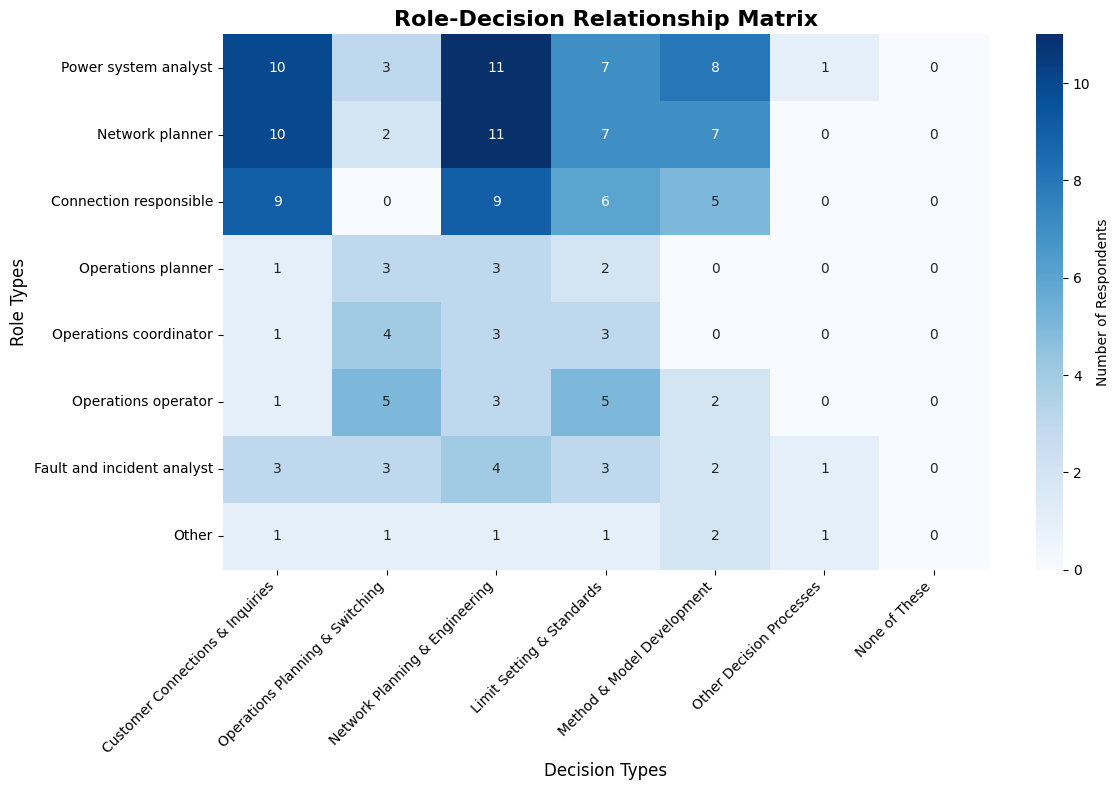

✅ Role-Decision heatmap created


In [19]:
def create_role_decision_heatmap(df_clean, mappings):
    """
    Create heatmap showing role-decision relationships
    """
    role_cols = [col for col in mappings['roles'].keys() if col in df_clean.columns]
    decision_cols = [col for col in mappings['decisions'].keys() if col in df_clean.columns]
    
    # Create matrix
    matrix_data = []
    role_labels = []
    decision_labels = []
    
    for role_col in role_cols:
        role_name = mappings['roles'][role_col]
        role_labels.append(role_name)
        row_data = []
        
        for decision_col in decision_cols:
            if len(decision_labels) < len(decision_cols):
                decision_labels.append(mappings['decisions'][decision_col])
            
            # Count overlap
            overlap = ((df_clean[role_col] == 1) & (df_clean[decision_col] == 1)).sum()
            row_data.append(overlap)
        
        matrix_data.append(row_data)
    
    # Create heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(matrix_data, 
                xticklabels=decision_labels,
                yticklabels=role_labels,
                annot=True, 
                fmt='d',
                cmap='Blues',
                cbar_kws={'label': 'Number of Respondents'})
    
    plt.title('Role-Decision Relationship Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Decision Types', fontsize=12)
    plt.ylabel('Role Types', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return matrix_data, role_labels, decision_labels

# Create the heatmap
matrix_data, role_labels, decision_labels = create_role_decision_heatmap(df_clean, mappings)
print("✅ Role-Decision heatmap created")


## Summary Statistics

In [20]:
def print_survey_summary(df_clean, mappings, flows):
    """
    Print summary statistics about the survey data
    """
    print("=" * 60)
    print("SURVEY DATA SUMMARY")
    print("=" * 60)
    
    print(f"Total Responses: {len(df_clean)}")
    print(f"Total Flows Created: {len(flows)}")
    
    # Role distribution
    print("\nROLE DISTRIBUTION:")
    role_cols = [col for col in mappings['roles'].keys() if col in df_clean.columns]
    for role_col in role_cols:
        count = (df_clean[role_col] == 1).sum()
        percentage = (count / len(df_clean)) * 100
        print(f"  • {mappings['roles'][role_col]}: {count} ({percentage:.1f}%)")
    
    # Decision involvement
    print("\nDECISION INVOLVEMENT:")
    decision_cols = [col for col in mappings['decisions'].keys() if col in df_clean.columns]
    for decision_col in decision_cols:
        count = (df_clean[decision_col] == 1).sum()
        percentage = (count / len(df_clean)) * 100
        print(f"  • {mappings['decisions'][decision_col]}: {count} ({percentage:.1f}%)")
    
    # Analysis types
    print("\nANALYSIS TYPES:")
    analysis_cols = [col for col in mappings['analysis_types'].keys() if col in df_clean.columns]
    for analysis_col in analysis_cols:
        count = (df_clean[analysis_col] == 1).sum()
        percentage = (count / len(df_clean)) * 100
        print(f"  • {mappings['analysis_types'][analysis_col]}: {count} ({percentage:.1f}%)")
    
    # Simulation types
    print("\nSIMULATION TYPES:")
    simulation_cols = [col for col in mappings['simulation_types'].keys() if col in df_clean.columns]
    for simulation_col in simulation_cols:
        count = (df_clean[simulation_col] == 1).sum()
        percentage = (count / len(df_clean)) * 100
        print(f"  • {mappings['simulation_types'][simulation_col]}: {count} ({percentage:.1f}%)")
    
    print("=" * 60)

# Print summary
print_survey_summary(df_clean, mappings, flows)


SURVEY DATA SUMMARY
Total Responses: 24
Total Flows Created: 114

ROLE DISTRIBUTION:
  • Power system analyst: 12 (50.0%)
  • Network planner: 11 (45.8%)
  • Connection responsible: 9 (37.5%)
  • Operations planner: 3 (12.5%)
  • Operations coordinator: 4 (16.7%)
  • Operations operator: 5 (20.8%)
  • Fault and incident analyst: 5 (20.8%)
  • Other: 3 (12.5%)

DECISION INVOLVEMENT:
  • Customer Connections & Inquiries: 15 (62.5%)
  • Operations Planning & Switching: 9 (37.5%)
  • Network Planning & Engineering: 18 (75.0%)
  • Limit Setting & Standards: 14 (58.3%)
  • Method & Model Development: 11 (45.8%)
  • Other Decision Processes: 3 (12.5%)
  • None of These: 0 (0.0%)

ANALYSIS TYPES:
  • Outage Analysis: 15 (62.5%)
  • Operations Planning Analysis: 8 (33.3%)
  • Load & Generation Modeling: 19 (79.2%)
  • Economic Analysis: 12 (50.0%)
  • Other Analysis: 4 (16.7%)
  • No Analysis: 2 (8.3%)

SIMULATION TYPES:
  • Load Flow Analysis: 22 (91.7%)
  • State Analysis: 8 (33.3%)
  • Stoch